In [ ]:
%pip install pandas seaborn matplotlib

In [1]:
import pandas as pd
import os, re, sys
import numpy as np

## List-to-method correspondences

In [2]:
def get_method_dict(file):
    method_dict = {'average' : 'average'}
    with open(file, 'r') as f:
        lines = [line.rstrip() for line in f.readlines()]
        i = 1
        for l in lines:
            match = re.search(r'^.+attrib=([^_]+)_mpd.+_thresh=([^_]+)_.+$', l)
            method = match.group(1)
            threshold = match.group(2)
            key = 'list' + str(i)
            method_dict[key] = method + '_' + threshold
            i += 1
    return method_dict


In [3]:
bcms_setimes_methods = get_method_dict('shibboleth/randomized_lists.bcms_setimes.txt')
bcms_twitter_methods = get_method_dict('shibboleth/randomized_lists.bcms_twitter.txt')
estonian_voro_methods = get_method_dict('shibboleth/randomized_lists.estonian_voro.txt')
finnish_suomi24_methods = get_method_dict('shibboleth/randomized_lists.finnish.txt')
german_jodel_methods = get_method_dict('shibboleth/randomized_lists.jodel.txt')
greek_dialects_methods = get_method_dict('shibboleth/randomized_lists.greek.txt')
scandinavian_slide_methods = get_method_dict('shibboleth/randomized_lists.scandinavian.txt')

In [4]:
bcms_setimes_methods_df = pd.DataFrame.from_dict(bcms_setimes_methods, orient='index', columns=['method'])
bcms_setimes_methods_df

,method
average,average
list1,loo_0.6
list2,loo_0.1
list3,shap_0.6
list4,shap_0.1
list5,ig_0.1
list6,lime_0.6
list7,lime_0.1
list8,ig_0.6


In [7]:
bcms_twitter_methods_df = pd.DataFrame.from_dict(bcms_twitter_methods, orient='index', columns=['method'])
bcms_twitter_methods_df

,method
average,average
list1,lime_0.6
list2,loo_0.1
list3,shap_0.1
list4,ig_0.6
list5,loo_0.6
list6,ig_0.1
list7,shap_0.6
list8,lime_0.1


In [9]:
estonian_voro_methods_df = pd.DataFrame.from_dict(estonian_voro_methods, orient='index', columns=['method'])
estonian_voro_methods_df

,method
average,average
list1,ig_0.6
list2,ig_0.1
list3,loo_0.1
list4,shap_0.6
list5,shap_0.1
list6,loo_0.6
list7,lime_0.6
list8,lime_0.1


In [10]:
finnish_suomi24_methods_df = pd.DataFrame.from_dict(finnish_suomi24_methods, orient='index', columns=['method'])
finnish_suomi24_methods_df

,method
average,average
list1,shap_0.6
list2,loo_0.6
list3,ig_0.6
list4,loo_0.1
list5,lime_0.6
list6,lime_0.1
list7,ig_0.1
list8,shap_0.1


In [11]:
greek_dialects_methods_df = pd.DataFrame.from_dict(greek_dialects_methods, orient='index', columns=['method'])
greek_dialects_methods_df

,method
average,average
list1,ig_0.6
list2,shap_0.1
list3,loo_0.1
list4,loo_0.6
list5,shap_0.6
list6,ig_0.1
list7,lime_0.6
list8,lime_0.1


In [12]:
german_jodel_methods_df = pd.DataFrame.from_dict(german_jodel_methods, orient='index', columns=['method'])
german_jodel_methods_df

,method
average,average
list1,ig_0.1
list2,ig_0.6
list3,lime_0.1
list4,lime_0.6
list5,shap_0.6
list6,shap_0.1
list7,loo_0.1
list8,loo_0.6


In [13]:
scandinavian_slide_methods_df = pd.DataFrame.from_dict(scandinavian_slide_methods, orient='index', columns=['method'])
scandinavian_slide_methods_df

,method
average,average
list1,lime_0.1
list2,ig_0.1
list3,shap_0.1
list4,shap_0.6
list5,loo_0.1
list6,loo_0.6
list7,ig_0.6
list8,lime_0.6


## Importing all lists and labelling them with list ID

In [14]:
def make_dataset_df(folder):
    dfs = list()
    files = os.listdir(folder)
    for file in files:
        if file.endswith('.csv'):
            print
            id = re.sub('.csv', '', file)
            df = pd.read_csv(folder + '/' + file)
            df['file'] = id
            dfs.append(df)
        elif file.endswith('.txt'):
            id = re.sub(r'.+\.(\d)\..*', r'list\1', file)
            df = pd.read_csv(folder + '/' + file, sep='\t')
            df['file'] = id
            dfs.append(df)
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

In [15]:
def get_number_annots(df):
    number_annots = df.value_counts('file').to_frame()
    number_annots = number_annots.rename(columns={number_annots.columns[0]: "total"})
    return number_annots

In [16]:
bcms_twitter_df = make_dataset_df('bcms_twitter')
bcms_twitter_df

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,čarobna,bs,0.706716,0.875000,NaN,no,unm,NaN,NaN,list1
1,čarolije,bs,0.658181,0.656250,NaN,no,unm,NaN,NaN,list1
2,čarolija,bs,0.643859,0.968750,NaN,no,unm,NaN,NaN,list1
3,fancyasfuck,bs,0.621885,0.739583,NaN,no,foreign,NaN,NaN,list1
4,allah,bs,0.591824,0.791667,NaN,yes,lex,spel,NaN,list1
...,...,...,...,...,...,...,...,...,...,...
3195,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,list8
3196,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,list8
3197,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,list8
3198,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,list8


In [17]:
bcms_setimes_df = make_dataset_df('bcms_setimes')
bcms_setimes_df

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,liječniku,hr,0.340325,0.60,True,yes,lex,NaN,jek,list1
1,slijedili,hr,0.232197,0.64,True,no,phon,NaN,jek,list1
2,razvitkom,hr,0.212817,0.75,True,yes,morph-d,NaN,NaN,list1
3,natjecateljskom,hr,0.194636,0.63,True,yes,lex,NaN,NaN,list1
4,sarachini,hr,0.190969,0.63,False,no,named entity,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...
1595,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,list8
1596,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,list8
1597,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,list8
1598,ignorisati,sr,0.361948,0.62,False,yes,morph-d,NaN,NaN,list8


In [18]:
estonian_voro_df = make_dataset_df('eesti-voro')
estonian_voro_df

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
2,käisid,käima,käümä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
3,võiksid,võima,võima,est,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
4,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,oppuslinõ,oppuslinõ,õpetlik,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8
1596,põhamaa,Põḣamaaq,Põhjamaad,vro,x,NaN,x,NaN,NaN,NaN,NaN,NaN,list8
1597,kooltõnõma,koolõnõma ?,!= hinge vaakuma,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1598,häügaq,häbü,häbi,vro,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8


In [19]:
german_jodel_df = make_dataset_df('german_jodel')
german_jodel_df

,token,label,score,selection_freq,code,other_variety,note,file
0,körndln,AT,0.976010,0.10,morph,NaN,not exclusive,list1
1,gfahrn?“,AT,0.942268,0.10,phon,NaN,not exclusive,list1
2,wien❤️,AT,0.930604,0.10,NE,NaN,NaN,list1
3,krems/stein/mautern,AT,0.917586,0.10,NE,NaN,NaN,list1
4,datinggschichtln,AT,0.892725,0.10,morph,NaN,NaN,list1
...,...,...,...,...,...,...,...,...
3195,heinerfest,DE_S,0.313043,0.87,NE,NaN,NaN,list8
3196,ilmenau,DE_S,0.312112,1.00,NE,NaN,NaN,list8
3197,heimkommen,DE_S,0.312046,0.74,unmarked,NaN,NaN,list8
3198,passau,DE_S,0.312020,0.97,NE,NaN,NaN,list8


In [20]:
german_jodel_df['other_variety'].value_counts()

yes    10
Yes     3
Name: other_variety, dtype: int64

In [21]:
greek_dialects_df = make_dataset_df('greek_dialects')
greek_dialects_df

,token,label,score,selection_freq,feature,file
0,γλεντίζει,CRE,0.768405,0.66,Morph,list1
1,κανελλατου.γρ,CRE,0.753272,0.97,NE,list1
2,μαργαριτάρι,CRE,0.645182,0.73,Unmarked,list1
3,εκράτει,CRE,0.643721,1.00,Morph,list1
4,κλουθήξει,CRE,0.618015,0.63,Morph,list1
...,...,...,...,...,...,...
3195,φρουροί,PON,0.373081,0.24,Unmarked,list8
3196,καρενέσε,PON,0.370964,0.10,Unmarked,list8
3197,μεξικού,PON,0.369579,0.96,NE,list8
3198,χλωρίζνε,PON,0.366267,0.10,Morph,list8


In [22]:
finnish_suomi24_df = make_dataset_df('finnish_suomi24')
finnish_suomi24_df

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,ollunna,east,0.379162,0.818182,morph,other,list1
1,1,hää,east,0.366869,0.989899,lex,lex,list1
2,2,aeka,east,0.361476,0.676768,phon,other,list1
3,3,minnuu,east,0.349316,0.828283,phon,other,list1
4,4,vaen,east,0.336384,0.848485,phon,other,list1
...,...,...,...,...,...,...,...,...
2015,295,mukulat,west,0.175638,0.101010,not,not,list8
2016,296,kauhavalaanen,west,0.175430,0.101010,phon,other,list8
2017,297,pikkase.kerros,west,0.174050,0.101010,not,not,list8
2018,298,vitsikäs,west,0.173803,0.101010,not,not,list8


In [23]:
scandinavian_slide_df = make_dataset_df('scandinavian_slide')
scandinavian_slide_df

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,uddannelsesinstitutionerne,da,0.996353,0.10,False,NaN,utdannelsesinstitusjonene,NaN,NaN,False,True,True,True,False,False,False,False,True,list1
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
2,2,forsigtigere,da,0.992772,0.10,False,NaN,forsiktigere,forsiktigare,försiktigare,False,False,False,True,False,False,False,False,True,list1
3,3,standardindstillingerne,da,0.992396,0.10,False,NaN,standardinnstillingene,standardinnstilling?,standardinställning?/lemma,False,True,True,False,False,False,False,False,True,list1
4,4,historiebøger,da,0.987946,0.10,False,NaN,bøker,NaN,böcker,False,True,False,True,False,False,False,False,True,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


# Data preparation

Aim: data frame containing the percentage of lexical shibboleths, other shibboleths, non shibboleths and if applicable other annotations

## Preparing bcms_setimes dataframe

In [24]:
number_annots = get_number_annots(bcms_setimes_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [25]:
bcms_setimes_shib_distro = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_setimes_shib_distro['nonlex shib'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] != 'lex')].groupby('file').size()
bcms_setimes_shib_distro['non shib'] = bcms_setimes_df[bcms_setimes_df['shibboleth'] == 'no'].groupby('file').size()
bcms_setimes_shib_distro['rest'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] != 'no') & (bcms_setimes_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, number_annots], axis=1)
bcms_setimes_shib_distro['shibboleths: lexical'] = round(bcms_setimes_shib_distro['lex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['shibboleths: other'] = round(bcms_setimes_shib_distro['nonlex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['non shibboleths'] = round(bcms_setimes_shib_distro['non shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['other'] = round(bcms_setimes_shib_distro['rest'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['perc sum'] = bcms_setimes_shib_distro['shibboleths: lexical'] + bcms_setimes_shib_distro['shibboleths: other'] \
+ bcms_setimes_shib_distro['non shibboleths'] + bcms_setimes_shib_distro['other']
bcms_setimes_shib_distro.loc['average'] = round(bcms_setimes_shib_distro.mean(axis=0), 1)
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0


In [26]:
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, bcms_setimes_methods_df], axis=1)


In [27]:
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0,loo_0.6
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0,loo_0.1
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN,shap_0.6
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0,shap_0.1
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0,ig_0.1
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0,lime_0.6
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0,lime_0.1
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN,ig_0.6
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0,average


In [28]:
bcms_setimes_shib_distro = bcms_setimes_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
bcms_setimes_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0
ig_0.1,list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
ig_0.6,list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
lime_0.1,list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
lime_0.6,list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
loo_0.1,list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
loo_0.6,list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
shap_0.1,list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
shap_0.6,list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN


In [29]:
bcms_setimes_overview = bcms_setimes_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_setimes_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,13.2,35.2,49.9,2.2
ig_0.1,10.0,29.0,60.0,1.0
ig_0.6,18.5,48.0,33.5,NaN
lime_0.1,11.0,44.0,41.0,4.0
lime_0.6,18.5,42.5,37.5,1.5
loo_0.1,7.0,24.5,65.5,3.0
loo_0.6,16.5,35.0,47.0,1.5
shap_0.1,7.5,22.5,67.5,2.5
shap_0.6,16.5,36.0,47.5,NaN


## Preparing bcms_twitter dataset

In [30]:
number_annots = get_number_annots(bcms_twitter_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [31]:
bcms_twitter_shib_distro = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_twitter_shib_distro['nonlex shib'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] != 'lex')].groupby('file').size()
bcms_twitter_shib_distro['non shib'] = bcms_twitter_df[bcms_twitter_df['shibboleth'] == 'no'].groupby('file').size()
bcms_twitter_shib_distro['rest'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] != 'no') & (bcms_twitter_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, number_annots], axis=1)
bcms_twitter_shib_distro['shibboleths: lexical'] = round(bcms_twitter_shib_distro['lex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['shibboleths: other'] = round(bcms_twitter_shib_distro['nonlex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['non shibboleths'] = round(bcms_twitter_shib_distro['non shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['other'] = round(bcms_twitter_shib_distro['rest'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['perc sum'] = bcms_twitter_shib_distro['shibboleths: lexical'] + bcms_twitter_shib_distro['shibboleths: other'] \
+ bcms_twitter_shib_distro['non shibboleths'] + bcms_twitter_shib_distro['other']
bcms_twitter_shib_distro.loc['average'] = round(bcms_twitter_shib_distro.mean(axis=0), 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0


In [32]:
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, bcms_twitter_methods_df], axis = 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1,lime_0.6
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0,loo_0.1
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0,shap_0.1
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9,ig_0.6
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9,loo_0.6
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0,ig_0.1
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0,shap_0.6
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0,lime_0.1
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0,average


In [33]:
bcms_twitter_shib_distro  = bcms_twitter_shib_distro.sort_values(by='method').reset_index(names=['list']).set_index('method')
bcms_twitter_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0
ig_0.1,list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
ig_0.6,list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
lime_0.1,list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
lime_0.6,list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
loo_0.1,list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
loo_0.6,list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
shap_0.1,list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
shap_0.6,list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0


In [34]:
bcms_twitter_overview = bcms_twitter_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_twitter_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,3.7,24.9,69.0,2.4
ig_0.1,4.0,19.8,73.2,3.0
ig_0.6,2.2,27.0,67.2,3.5
lime_0.1,5.2,28.2,64.8,1.8
lime_0.6,3.8,27.3,67.0,2.0
loo_0.1,3.2,19.5,75.5,1.8
loo_0.6,2.2,24.2,71.0,2.5
shap_0.1,4.8,25.0,68.2,2.0
shap_0.6,4.0,28.0,65.5,2.5


## Preparing german_jodel dataframe

In [35]:
number_annots = get_number_annots(german_jodel_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [36]:
german_jodel_df.value_counts('code')

code
NE          1982
unmarked     401
phon         346
lex          278
morph        187
spell          5
other          1
dtype: int64

In [37]:
# Named entities are not shibboleths
# Only single-variety shibboleths count
german_jodel_df['shibboleth'] = 'no'
german_jodel_df.loc[(german_jodel_df['code'] != 'NE') & (german_jodel_df['code'] != 'unmarked') \
& (german_jodel_df['other_variety'].isna()) & (german_jodel_df['note'].isna()) , 'shibboleth'] = 'yes'
# sanity check:
german_jodel_df[(german_jodel_df['code'] == 'lex') & (german_jodel_df['shibboleth'] == 'no')]

,token,label,score,selection_freq,code,other_variety,note,file,shibboleth
17,leberzirrhoseahoii,AT,0.733379,0.10,lex,yes,NaN,list1,no
309,okaygehtwohlnixmehrinmeinenkopfrein#prüfungsph...,DE_S,1.165360,0.10,lex,yes,NaN,list1,no
442,amal,AT,0.274777,1.00,lex,NaN,not exclusive,list4,no
456,gscheit,AT,0.241944,0.63,lex,NaN,not exclusive,list4,no
476,matura,AT,0.203438,0.85,lex,NaN,not exclusive,list4,no
485,schaun,AT,0.185014,1.00,lex,NaN,not exclusive,list4,no
486,schaut,AT,0.173890,1.00,lex,NaN,not exclusive,list4,no
489,fesch,AT,0.172758,0.79,lex,NaN,not exclusive,list4,no
492,ausschaun,AT,0.171567,0.64,lex,NaN,not exclusive,list4,no
826,schaun,AT,0.400855,1.00,lex,NaN,not exclusive,list2,no


In [38]:
german_jodel_shib_distro = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
german_jodel_shib_distro['nonlex shib'] = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] != 'lex')].groupby('file').size()
german_jodel_shib_distro['non shib'] = german_jodel_df[german_jodel_df['shibboleth'] == 'no'].groupby('file').size()
german_jodel_shib_distro.loc[:,'sum'] = german_jodel_shib_distro.sum(axis=1)
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, number_annots], axis=1)
german_jodel_shib_distro['shibboleths: lexical'] = round(german_jodel_shib_distro['lex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['shibboleths: other'] = round(german_jodel_shib_distro['nonlex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['non shibboleths'] = round(german_jodel_shib_distro['non shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['perc_sum'] = german_jodel_shib_distro['shibboleths: lexical'] + german_jodel_shib_distro['shibboleths: other'] + german_jodel_shib_distro['non shibboleths']
german_jodel_shib_distro.loc['average'] = round(german_jodel_shib_distro.mean(axis=0), 1)

german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0


In [39]:
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, german_jodel_methods_df], axis=1)
german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9,ig_0.1
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0,ig_0.6
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0,lime_0.1
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1,lime_0.6
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1,shap_0.6
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0,shap_0.1
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0,loo_0.1
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9,loo_0.6
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0,average


In [40]:
german_jodel_shib_distro = german_jodel_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
german_jodel_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0
ig_0.1,list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
ig_0.6,list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
lime_0.1,list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
lime_0.6,list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
loo_0.1,list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
loo_0.6,list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
shap_0.1,list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
shap_0.6,list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1


In [41]:
german_jodel_overview = german_jodel_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
german_jodel_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.9,14.1,78.0
ig_0.1,14.2,13.5,72.2
ig_0.6,5.0,17.2,77.8
lime_0.1,11.0,14.2,74.8
lime_0.6,5.8,12.5,81.8
loo_0.1,7.2,15.0,77.8
loo_0.6,5.2,10.5,84.2
shap_0.1,10.0,14.8,75.2
shap_0.6,4.8,14.8,80.5


## Preparing greek_dialects dataframe

In [42]:
greek_dialects_df[greek_dialects_df['file'] ==  'list2']

,token,label,score,selection_freq,feature,file
800,θυμάται_στο,CRE,1.024675,0.10,Unmarked,list2
801,μετακινήσω,CRE,1.009906,0.10,Unmarked,list2
802,ακροατή/αναγνώστη,CRE,1.003343,0.10,Unmarked,list2
803,ξεφωνήση,CRE,0.999911,0.10,Morph,list2
804,ξεπρήσθη,CRE,0.999860,0.10,Morph,list2
...,...,...,...,...,...,...
1195,τιούτσεβα,PON,0.213957,0.25,NE,list2
1196,επεστάθεν,PON,0.212394,0.34,Lex,list2
1197,ασατήν,PON,0.212127,0.10,Lex,list2
1198,οροπέδιο,PON,0.211999,0.10,Unmarked,list2


In [43]:
greek_dialects_df.value_counts('feature')

feature
Unmarked    1516
Phon         604
NE           420
Lex          342
Morph        312
Other          3
I              1
Spell          1
ΝΕ             1
dtype: int64

In [44]:
number_annots = get_number_annots(greek_dialects_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [45]:
greek_dialects_shib_distro = greek_dialects_df[greek_dialects_df['feature'] == 'Lex'].groupby('file').size().to_frame(name='lex shib')
greek_dialects_shib_distro['nonlex shib'] = greek_dialects_df[(greek_dialects_df['feature'] != 'NE') & (greek_dialects_df['feature'] != 'Unmarked') & (greek_dialects_df['feature'] != 'Lex')].groupby('file').size()
greek_dialects_shib_distro['non shib'] = greek_dialects_df[(greek_dialects_df['feature'] == 'NE') | (greek_dialects_df['feature'] == 'Unmarked')].groupby('file').size()
greek_dialects_shib_distro.loc[:, 'sum'] = greek_dialects_shib_distro.sum(axis=1)
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, number_annots], axis=1)
greek_dialects_shib_distro['shibboleths: lexical'] = round(greek_dialects_shib_distro['lex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['shibboleths: other'] = round(greek_dialects_shib_distro['nonlex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['non shibboleths'] = round(greek_dialects_shib_distro['non shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['perc_sum'] = greek_dialects_shib_distro['shibboleths: lexical'] + greek_dialects_shib_distro['shibboleths: other'] \
+ greek_dialects_shib_distro['non shibboleths']
greek_dialects_shib_distro.loc['average'] = round(greek_dialects_shib_distro.mean(axis=0) , 1)

greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0


In [46]:
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, greek_dialects_methods_df], axis=1)
greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0,ig_0.6
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0,shap_0.1
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0,loo_0.1
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0,loo_0.6
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0,shap_0.6
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0,ig_0.1
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1,lime_0.6
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0,lime_0.1
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0,average


In [47]:
greek_dialects_shib_distro = greek_dialects_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
greek_dialects_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0
ig_0.1,list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
ig_0.6,list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
lime_0.1,list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
lime_0.6,list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
loo_0.1,list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
loo_0.6,list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
shap_0.1,list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
shap_0.6,list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0


In [48]:
greek_dialects_overview = greek_dialects_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
greek_dialects_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,10.7,28.8,60.5
ig_0.1,18.0,27.0,55.0
ig_0.6,18.5,41.0,40.5
lime_0.1,10.5,32.0,57.5
lime_0.6,7.8,23.5,68.8
loo_0.1,6.2,20.0,73.8
loo_0.6,7.5,18.0,74.5
shap_0.1,9.5,30.5,60.0
shap_0.6,7.5,38.5,54.0


## Preparing finnish_suomi24 dataframe

In [49]:
finnish_suomi24_df

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,ollunna,east,0.379162,0.818182,morph,other,list1
1,1,hää,east,0.366869,0.989899,lex,lex,list1
2,2,aeka,east,0.361476,0.676768,phon,other,list1
3,3,minnuu,east,0.349316,0.828283,phon,other,list1
4,4,vaen,east,0.336384,0.848485,phon,other,list1
...,...,...,...,...,...,...,...,...
2015,295,mukulat,west,0.175638,0.101010,not,not,list8
2016,296,kauhavalaanen,west,0.175430,0.101010,phon,other,list8
2017,297,pikkase.kerros,west,0.174050,0.101010,not,not,list8
2018,298,vitsikäs,west,0.173803,0.101010,not,not,list8


In [50]:
finnish_suomi24_df.value_counts('label')

label
north    680
east     673
west     667
dtype: int64

In [51]:
number_annots = get_number_annots(finnish_suomi24_df)
number_annots

,total
file,
list4,300
list6,300
list7,300
list8,300
list5,221
list2,207
list1,206
list3,186


In [53]:
finnish_suomi24_shib_distro = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'lex'].groupby('file').size().to_frame(name='lex shib')
finnish_suomi24_shib_distro['nonlex shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'other'].groupby('file').size()
finnish_suomi24_shib_distro['non shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] ==  'not'].groupby('file').size()
finnish_suomi24_shib_distro.loc[:, 'sum'] = finnish_suomi24_shib_distro.sum(axis=1)
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, number_annots], axis=1)
finnish_suomi24_shib_distro['shibboleths: lexical'] = round(finnish_suomi24_shib_distro['lex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['shibboleths: other'] = round(finnish_suomi24_shib_distro['nonlex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['non shibboleths'] = round(finnish_suomi24_shib_distro['non shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['perc_sum'] = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']].sum(axis=1)
finnish_suomi24_shib_distro.loc['average'] = round(finnish_suomi24_shib_distro.mean(axis=0), 1)


finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0


In [54]:
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, finnish_suomi24_methods_df], axis=1)
finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0,shap_0.6
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0,loo_0.6
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0,ig_0.6
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0,loo_0.1
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0,lime_0.6
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0,lime_0.1
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0,ig_0.1
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0,shap_0.1
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0,average


In [55]:
finnish_suomi24_shib_distro = finnish_suomi24_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
finnish_suomi24_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0
ig_0.1,list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
ig_0.6,list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
lime_0.1,list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
lime_0.6,list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
loo_0.1,list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
loo_0.6,list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
shap_0.1,list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
shap_0.6,list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0


In [56]:
finnish_suomi24_overview = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
finnish_suomi24_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.5,44.4,48.0
ig_0.1,3.0,62.0,35.0
ig_0.6,10.2,22.6,67.2
lime_0.1,7.0,67.0,26.0
lime_0.6,9.5,24.9,65.6
loo_0.1,5.7,65.3,29.0
loo_0.6,10.1,21.3,68.6
shap_0.1,5.3,68.7,26.0
shap_0.6,9.2,23.8,67.0


## Prepare estonian-voro dataframe

In [57]:
estonian_voro_df

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
2,käisid,käima,käümä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
3,võiksid,võima,võima,est,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
4,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,oppuslinõ,oppuslinõ,õpetlik,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8
1596,põhamaa,Põḣamaaq,Põhjamaad,vro,x,NaN,x,NaN,NaN,NaN,NaN,NaN,list8
1597,kooltõnõma,koolõnõma ?,!= hinge vaakuma,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1598,häügaq,häbü,häbi,vro,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8


In [58]:
number_annots = get_number_annots(estonian_voro_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [59]:
estonian_voro_df[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False)]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
6,tõusis,tõusma,!= nõsõma,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
12,vaatas,vaatama,!= kaema,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
13,hakkasid,hakkama,!= nakkama,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,pedäjän,petäi,!= mänd (but dictionaries mention the cognates...,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1584,saibidõgaq,saivas,!= teivas,vro,xx,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1587,vererõuhkust,vererõuhkus,!=? vererõhk,vro,x,x,NaN,NaN,NaN,NaN,derivation,NaN,list8
1590,miihämmätüse,? hämmätüs,? != kaste; sous,vro,x,x,NaN,x,NaN,x,virhe ?,NaN,list8


In [60]:
estonian_voro_df["unk"] = 0
estonian_voro_df.loc[(estonian_voro_df['Unknown'].str.contains('x', na=False) | estonian_voro_df['Other'].str.contains('x', na=False)), "unk"] = 1
estonian_voro_df["noshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & estonian_voro_df['Unmarked'].str.contains('x', na=False)), "noshib"] = 1
estonian_voro_df["lexshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & (estonian_voro_df["noshib"] == 0) & estonian_voro_df['Lexicon'].str.contains('x', na=False)), "lexshib"] = 1
estonian_voro_df["nonlexshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & (estonian_voro_df["noshib"] == 0) & (estonian_voro_df["lexshib"] == 0) & estonian_voro_df['Phon-Morph-infl-Morph-der-Spelling'].str.contains(r'x|s', na=False)), "nonlexshib"] = 1

estonian_voro_df.loc[estonian_voro_df["unk"] + estonian_voro_df["noshib"] + estonian_voro_df["lexshib"] + estonian_voro_df["nonlexshib"] == 0, "unk"] += 1

estonian_voro_df[estonian_voro_df["unk"] >= 1]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file,unk,noshib,lexshib,nonlexshib
31,kasvavad,kasvama,kasuma,est,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1,1,0,0,0
144,põlvan,Põlva?,Põlva?,vro,NaN,NaN,?,NaN,NaN,NaN,NaN,NaN,list1,1,0,0,0
307,nal,? tokenisation mistakenly splitting nal´alt?,?,vro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list4,1,0,0,0
423,seinapraod,seinapragu,?,est,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list2,1,0,0,0
499,varrepoolne,varrepoolne,?,est,NaN,NaN,NaN,NaN,NaN,x,NaN,NaN,list2,1,0,0,0
541,võsudsõ,?,< võsa,vro,x,NaN,NaN,NaN,NaN,x,NaN,NaN,list2,1,0,0,0
543,hõds'usuu,hõdśosuu,õõtsiksoo,vro,x,NaN,NaN,NaN,NaN,x,(hõtsk,gen. hõdso),list2,1,0,0,0
562,393,NaN,NaN,vro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list2,1,0,0,0
566,tsokõrdaja,tśokõrdama,"? (in dictionary only explanation ""metsaveotra...",vro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list2,1,0,0,0
673,pandi,panema,pandma,est,NaN,NaN,NaN,x,NaN,NaN,NaN,NaN,list7,1,0,0,0


In [61]:
estonian_voro_shib_distro = estonian_voro_df[estonian_voro_df['lexshib']==1].groupby('file').size().to_frame(name="lex shib")
estonian_voro_shib_distro['non lex shib'] = estonian_voro_df[estonian_voro_df['nonlexshib']==1].groupby('file').size()
estonian_voro_shib_distro['non shib'] = estonian_voro_df[estonian_voro_df['noshib']==1].groupby('file').size()
estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['unk']==1].groupby('file').size()
estonian_voro_shib_distro.loc[:, 'sum'] = estonian_voro_shib_distro.sum(axis=1)

estonian_voro_shib_distro = pd.concat([estonian_voro_shib_distro, number_annots], axis=1)
estonian_voro_shib_distro['shibboleths: lexical'] = round(estonian_voro_shib_distro['lex shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['shibboleths: other'] = round(estonian_voro_shib_distro['non lex shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['non shibboleths'] = round(estonian_voro_shib_distro['non shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['other'] = round(estonian_voro_shib_distro['rest'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)

estonian_voro_shib_distro.loc[:, 'perc_sum'] = estonian_voro_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)
estonian_voro_shib_distro.loc['average'] = round(estonian_voro_shib_distro.mean(axis=0), 1)

estonian_voro_shib_distro

,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
file,,,,,,,,,,,
list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0
list2,73.0,114.0,7.0,6.0,200.0,200.0,36.5,57.0,3.5,3.0,100.0
list3,53.0,132.0,7.0,8.0,200.0,200.0,26.5,66.0,3.5,4.0,100.0
list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0
list5,55.0,135.0,4.0,6.0,200.0,200.0,27.5,67.5,2.0,3.0,100.0
list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0
list7,18.0,139.0,42.0,1.0,200.0,200.0,9.0,69.5,21.0,0.5,100.0
list8,57.0,132.0,2.0,9.0,200.0,200.0,28.5,66.0,1.0,4.5,100.0
average,41.4,136.6,17.6,4.4,200.0,200.0,20.7,68.3,8.8,2.2,100.0


In [62]:
estonian_voro_shib_distro = pd.concat([estonian_voro_shib_distro, estonian_voro_methods_df], axis=1)
estonian_voro_shib_distro

,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum,method
list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0,ig_0.6
list2,73.0,114.0,7.0,6.0,200.0,200.0,36.5,57.0,3.5,3.0,100.0,ig_0.1
list3,53.0,132.0,7.0,8.0,200.0,200.0,26.5,66.0,3.5,4.0,100.0,loo_0.1
list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0,shap_0.6
list5,55.0,135.0,4.0,6.0,200.0,200.0,27.5,67.5,2.0,3.0,100.0,shap_0.1
list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0,loo_0.6
list7,18.0,139.0,42.0,1.0,200.0,200.0,9.0,69.5,21.0,0.5,100.0,lime_0.6
list8,57.0,132.0,2.0,9.0,200.0,200.0,28.5,66.0,1.0,4.5,100.0,lime_0.1
average,41.4,136.6,17.6,4.4,200.0,200.0,20.7,68.3,8.8,2.2,100.0,average


In [63]:
estonian_voro_shib_distro = estonian_voro_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
estonian_voro_shib_distro

,list,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
method,,,,,,,,,,,,
average,average,41.4,136.6,17.6,4.4,200.0,200.0,20.7,68.3,8.8,2.2,100.0
ig_0.1,list2,73.0,114.0,7.0,6.0,200.0,200.0,36.5,57.0,3.5,3.0,100.0
ig_0.6,list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0
lime_0.1,list8,57.0,132.0,2.0,9.0,200.0,200.0,28.5,66.0,1.0,4.5,100.0
lime_0.6,list7,18.0,139.0,42.0,1.0,200.0,200.0,9.0,69.5,21.0,0.5,100.0
loo_0.1,list3,53.0,132.0,7.0,8.0,200.0,200.0,26.5,66.0,3.5,4.0,100.0
loo_0.6,list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0
shap_0.1,list5,55.0,135.0,4.0,6.0,200.0,200.0,27.5,67.5,2.0,3.0,100.0
shap_0.6,list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0


In [64]:
estonian_voro_overview = estonian_voro_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
estonian_voro_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,20.7,68.3,8.8,2.2
ig_0.1,36.5,57.0,3.5,3.0
ig_0.6,17.5,73.5,8.0,1.0
lime_0.1,28.5,66.0,1.0,4.5
lime_0.6,9.0,69.5,21.0,0.5
loo_0.1,26.5,66.0,3.5,4.0
loo_0.6,9.0,70.5,19.5,1.0
shap_0.1,27.5,67.5,2.0,3.0
shap_0.6,11.0,76.5,12.0,0.5


## Prepare scandinavian_slide dataframe

In [65]:
scandinavian_slide_df

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,uddannelsesinstitutionerne,da,0.996353,0.10,False,NaN,utdannelsesinstitusjonene,NaN,NaN,False,True,True,True,False,False,False,False,True,list1
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
2,2,forsigtigere,da,0.992772,0.10,False,NaN,forsiktigere,forsiktigare,försiktigare,False,False,False,True,False,False,False,False,True,list1
3,3,standardindstillingerne,da,0.992396,0.10,False,NaN,standardinnstillingene,standardinnstilling?,standardinställning?/lemma,False,True,True,False,False,False,False,False,True,list1
4,4,historiebøger,da,0.987946,0.10,False,NaN,bøker,NaN,böcker,False,True,False,True,False,False,False,False,True,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


In [66]:
scandinavian_slide_df[(scandinavian_slide_df['NE'] == True) & (scandinavian_slide_df['NonLexShib'] == True)]

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
30,30,præsidentrådet,da,0.904034,0.10,False,NaN,presidentrådet,NaN,ministerrådet,False,False,False,True,True,False,False,False,True,list1
213,213,noregscupfinalen,nn,0.960627,0.10,False,NaN,norges,NaN,NaN,False,True,False,False,True,False,False,False,True,list1
242,242,seljordingane,nn,0.877505,0.10,False,NaN,seljordingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
246,246,seljordingar,nn,0.850857,0.10,False,NaN,seljordinger,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
252,252,sveitsar,nn,0.831450,0.10,False,schweizer,sveitser,NaN,schweizare,False,False,True,True,True,False,False,False,True,list1
286,286,telemarkingane,nn,0.673509,0.10,False,NaN,telemarkingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
349,349,kontanthjälp,sv,0.762978,0.10,False,kontanthjælp,NaN,NaN,NaN,False,False,False,True,True,False,False,False,True,list1
432,32,græsk,da,0.566233,0.75,True,NaN,gresk,gresk,grekisk,False,False,False,True,True,False,False,False,True,list4
613,213,amerikanarane,nn,0.088973,0.60,False,NaN,amerikanerne,NaN,amerikanarna,False,False,True,False,True,False,False,False,True,list4


In [67]:
number_annots = get_number_annots(scandinavian_slide_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [68]:
scandinavian_slide_shib_distro = scandinavian_slide_df[scandinavian_slide_df['LexShib'] == True].groupby('file').size().to_frame(name='lex shib')
scandinavian_slide_shib_distro['nonlex shib'] = scandinavian_slide_df[scandinavian_slide_df['NonLexShib'] == True].groupby('file').size()
scandinavian_slide_shib_distro['non shib'] = scandinavian_slide_df[(scandinavian_slide_df['NotShib'] ==  True)].groupby('file').size()
scandinavian_slide_shib_distro['rest'] = scandinavian_slide_df[(scandinavian_slide_df['Typo_Unk'] == True)].groupby('file').size()
scandinavian_slide_shib_distro.loc[:, 'sum'] = scandinavian_slide_shib_distro.sum(axis=1)
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, number_annots], axis=1)

scandinavian_slide_shib_distro['shibboleths: lexical'] = round(scandinavian_slide_shib_distro['lex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['shibboleths: other'] = round(scandinavian_slide_shib_distro['nonlex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['non shibboleths'] = round(scandinavian_slide_shib_distro['non shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['other'] = round(scandinavian_slide_shib_distro['rest'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)

scandinavian_slide_shib_distro.loc[:, 'perc_sum'] = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)

scandinavian_slide_shib_distro.loc['average'] = round(scandinavian_slide_shib_distro.mean(axis=0), 1)

scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
file,,,,,,,,,,,
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0


In [69]:
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, scandinavian_slide_methods_df], axis=1)
scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum,method
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8,lime_0.1
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9,ig_0.1
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1,shap_0.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0,shap_0.6
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0,loo_0.1
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0,loo_0.6
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0,ig_0.6
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0,lime_0.6
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0,average


In [70]:
scandinavian_slide_shib_distro = scandinavian_slide_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
scandinavian_slide_shib_distro

,list,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
method,,,,,,,,,,,,
average,average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0
ig_0.1,list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
ig_0.6,list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
lime_0.1,list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
lime_0.6,list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
loo_0.1,list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
loo_0.6,list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
shap_0.1,list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
shap_0.6,list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0


In [71]:
scandinavian_slide_overview = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
scandinavian_slide_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,18.8,52.9,26.4,2.9
ig_0.1,24.2,51.2,19.0,5.5
ig_0.6,15.2,53.8,31.0,NaN
lime_0.1,19.2,54.2,23.2,3.2
lime_0.6,15.8,52.2,31.8,0.2
loo_0.1,19.2,53.2,24.8,2.8
loo_0.6,16.5,49.0,34.5,NaN
shap_0.1,23.8,55.5,17.8,3.0
shap_0.6,16.8,54.2,29.0,NaN


## Generate graphs

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

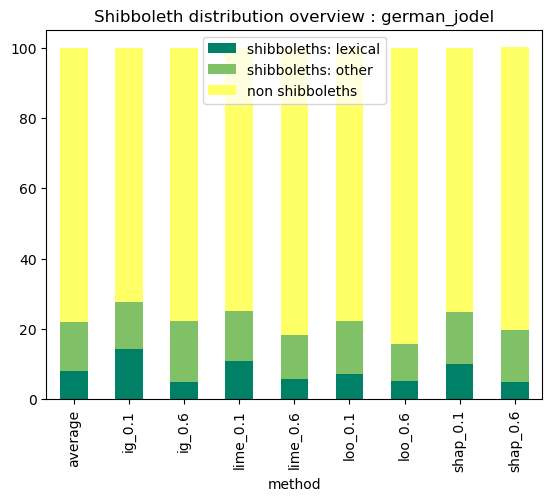

In [73]:
german_jodel_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : german_jodel").figure.savefig('german_jodel_shib_overview.pdf', bbox_inches='tight')

In [ ]:
bcms_twitter_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : bcms_twitter").figure.savefig('bcms_twitter_shib_overview.pdf', bbox_inches='tight')

In [ ]:
bcms_setimes_overview.plot(kind='bar', colormap="summer", stacked=True, title="Shibboleth distribution overview : bcms_setimes").figure.savefig('bcms_setimes_shib_overview.pdf', bbox_inches='tight')

In [ ]:
greek_dialects_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : greek_dialects").figure.savefig('greek_dialects_shib_overview.pdf', bbox_inches='tight')

In [ ]:
finnish_suomi24_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : finnish_suomi24").figure.savefig('finnish_suomi24_shib_overview.pdf', bbox_inches='tight')

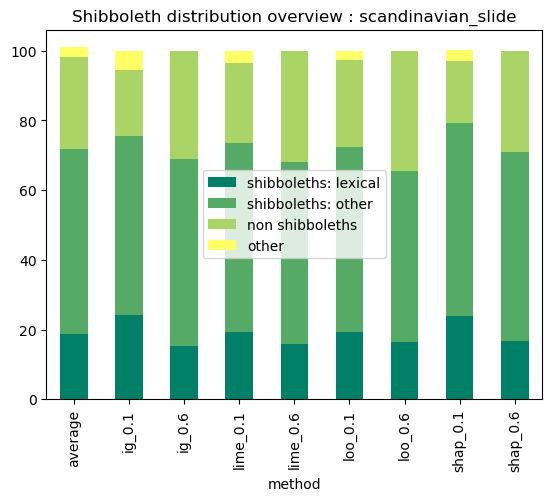

In [69]:
scandinavian_slide_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : scandinavian_slide").figure.savefig('scandinavian_slide_shib_overview.pdf', bbox_inches='tight')

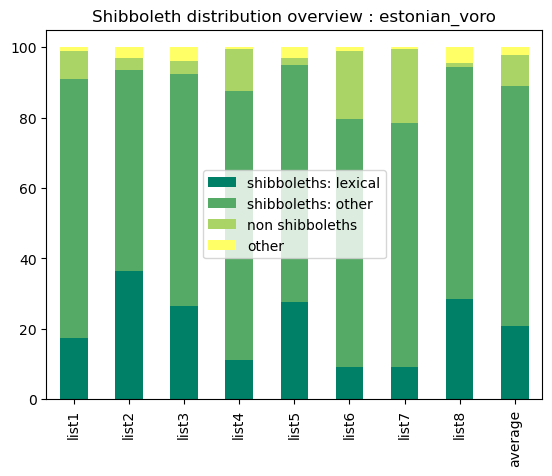

In [70]:
estonian_voro_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : estonian_voro").figure.savefig('estonian_voro_shib_overview.pdf', bbox_inches='tight')

## Generating csv tables with main results

In [74]:
bcms_setimes_overview.to_csv('bcms_setimes_overview.csv')
bcms_twitter_overview.to_csv('bcms_twitter_overview.csv')
finnish_suomi24_overview.to_csv('finnish_suomi24_overview.csv')
german_jodel_overview.to_csv('german_jodel_overview.csv')
greek_dialects_overview.to_csv('greek_dialects_overview.csv')
scandinavian_slide_overview.to_csv('scandinavian_slide_overview.csv')
estonian_voro_overview.to_csv('estonian_voro_overview.csv')

# Analysis by method 

In [75]:
bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'
bcms_setimes_overview

/tmp/ipykernel_5936/114774054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,13.2,35.2,49.9,2.2,bcms_setimes
ig_0.1,10.0,29.0,60.0,1.0,bcms_setimes
ig_0.6,18.5,48.0,33.5,NaN,bcms_setimes
lime_0.1,11.0,44.0,41.0,4.0,bcms_setimes
lime_0.6,18.5,42.5,37.5,1.5,bcms_setimes
loo_0.1,7.0,24.5,65.5,3.0,bcms_setimes
loo_0.6,16.5,35.0,47.0,1.5,bcms_setimes
shap_0.1,7.5,22.5,67.5,2.5,bcms_setimes
shap_0.6,16.5,36.0,47.5,NaN,bcms_setimes


In [76]:
bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'
bcms_twitter_overview

/tmp/ipykernel_5936/3093288178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,3.7,24.9,69.0,2.4,bcms_twitter
ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter


In [77]:
finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'
finnish_suomi24_overview

/tmp/ipykernel_5936/3544459959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.5,44.4,48.0,finnish_suomi24
ig_0.1,3.0,62.0,35.0,finnish_suomi24
ig_0.6,10.2,22.6,67.2,finnish_suomi24
lime_0.1,7.0,67.0,26.0,finnish_suomi24
lime_0.6,9.5,24.9,65.6,finnish_suomi24
loo_0.1,5.7,65.3,29.0,finnish_suomi24
loo_0.6,10.1,21.3,68.6,finnish_suomi24
shap_0.1,5.3,68.7,26.0,finnish_suomi24
shap_0.6,9.2,23.8,67.0,finnish_suomi24


In [78]:
german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'
german_jodel_overview

/tmp/ipykernel_5936/3181395630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.9,14.1,78.0,german_jodel
ig_0.1,14.2,13.5,72.2,german_jodel
ig_0.6,5.0,17.2,77.8,german_jodel
lime_0.1,11.0,14.2,74.8,german_jodel
lime_0.6,5.8,12.5,81.8,german_jodel
loo_0.1,7.2,15.0,77.8,german_jodel
loo_0.6,5.2,10.5,84.2,german_jodel
shap_0.1,10.0,14.8,75.2,german_jodel
shap_0.6,4.8,14.8,80.5,german_jodel


In [79]:
greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'
greek_dialects_overview

/tmp/ipykernel_5936/3640696615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,10.7,28.8,60.5,greek_dialects
ig_0.1,18.0,27.0,55.0,greek_dialects
ig_0.6,18.5,41.0,40.5,greek_dialects
lime_0.1,10.5,32.0,57.5,greek_dialects
lime_0.6,7.8,23.5,68.8,greek_dialects
loo_0.1,6.2,20.0,73.8,greek_dialects
loo_0.6,7.5,18.0,74.5,greek_dialects
shap_0.1,9.5,30.5,60.0,greek_dialects
shap_0.6,7.5,38.5,54.0,greek_dialects


In [80]:
scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'
scandinavian_slide_overview

/tmp/ipykernel_5936/265752419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,18.8,52.9,26.4,2.9,scandinavian_slide
ig_0.1,24.2,51.2,19.0,5.5,scandinavian_slide
ig_0.6,15.2,53.8,31.0,NaN,scandinavian_slide
lime_0.1,19.2,54.2,23.2,3.2,scandinavian_slide
lime_0.6,15.8,52.2,31.8,0.2,scandinavian_slide
loo_0.1,19.2,53.2,24.8,2.8,scandinavian_slide
loo_0.6,16.5,49.0,34.5,NaN,scandinavian_slide
shap_0.1,23.8,55.5,17.8,3.0,scandinavian_slide
shap_0.6,16.8,54.2,29.0,NaN,scandinavian_slide


In [81]:
estonian_voro_overview.loc[:, 'dataset'] = 'estonian_voro'
estonian_voro_overview

/tmp/ipykernel_5936/3872683280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estonian_voro_overview.loc[:, 'dataset'] = 'estonian_voro'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,20.7,68.3,8.8,2.2,estonian_voro
ig_0.1,36.5,57.0,3.5,3.0,estonian_voro
ig_0.6,17.5,73.5,8.0,1.0,estonian_voro
lime_0.1,28.5,66.0,1.0,4.5,estonian_voro
lime_0.6,9.0,69.5,21.0,0.5,estonian_voro
loo_0.1,26.5,66.0,3.5,4.0,estonian_voro
loo_0.6,9.0,70.5,19.5,1.0,estonian_voro
shap_0.1,27.5,67.5,2.0,3.0,estonian_voro
shap_0.6,11.0,76.5,12.0,0.5,estonian_voro


In [82]:
all_overview = pd.concat([bcms_twitter_overview, bcms_setimes_overview, finnish_suomi24_overview, \
                         german_jodel_overview, greek_dialects_overview, scandinavian_slide_overview, estonian_voro_overview], axis=0).reset_index(names=['method'])

all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
0,average,3.7,24.9,69.0,2.4,bcms_twitter
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
3,lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
4,lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
...,...,...,...,...,...,...
58,lime_0.6,9.0,69.5,21.0,0.5,estonian_voro
59,loo_0.1,26.5,66.0,3.5,4.0,estonian_voro
60,loo_0.6,9.0,70.5,19.5,1.0,estonian_voro
61,shap_0.1,27.5,67.5,2.0,3.0,estonian_voro


In [83]:
all_overview[all_overview['method'] == 'ig_0.1'].set_index('dataset')

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,ig_0.1,4.0,19.8,73.2,3.0
bcms_setimes,ig_0.1,10.0,29.0,60.0,1.0
finnish_suomi24,ig_0.1,3.0,62.0,35.0,NaN
german_jodel,ig_0.1,14.2,13.5,72.2,NaN
greek_dialects,ig_0.1,18.0,27.0,55.0,NaN
scandinavian_slide,ig_0.1,24.2,51.2,19.0,5.5
estonian_voro,ig_0.1,36.5,57.0,3.5,3.0


## Generate graphs by method

In [84]:
import matplotlib.cm as cm
import numpy as np

In [84]:
mean_lex_df = all_overview[all_overview['method'] == 'average'] #reset_index(names=['dataset'])
mean_lex_df.set_index('dataset', inplace=True)
mean_lex_df

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,average,3.7,24.9,69.0,2.4
bcms_setimes,average,13.2,35.2,49.9,2.2
finnish_suomi24,average,7.5,44.4,48.0,NaN
german_jodel,average,7.9,14.1,78.0,NaN
greek_dialects,average,10.7,28.8,60.5,NaN
scandinavian_slide,average,18.8,52.9,26.4,2.9
estonian_voro,average,20.7,68.3,8.8,2.2


In [85]:
mean_ev = mean_lex_df.loc['estonian_voro', 'shibboleths: lexical']
mean_twit = mean_lex_df.loc['bcms_twitter', 'shibboleths: lexical']
mean_set = mean_lex_df.loc['bcms_setimes', 'shibboleths: lexical']
mean_suomi24 = mean_lex_df.loc['finnish_suomi24', 'shibboleths: lexical']
mean_jodel = mean_lex_df.loc['german_jodel', 'shibboleths: lexical']
mean_greek = mean_lex_df.loc['greek_dialects', 'shibboleths: lexical']
mean_slide = mean_lex_df.loc['scandinavian_slide', 'shibboleths: lexical']

In [86]:
all_overview = all_overview[all_overview['method'] != 'average']
all_overview


,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
3,lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
4,lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
5,loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
6,loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
7,shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
8,shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter
10,ig_0.1,10.0,29.0,60.0,1.0,bcms_setimes
11,ig_0.6,18.5,48.0,33.5,NaN,bcms_setimes


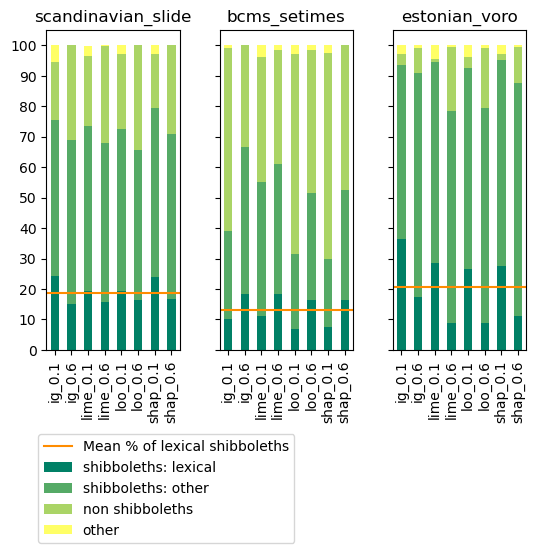

In [87]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey='row', figsize=(6,4))
all_overview[all_overview['dataset'] == 'scandinavian_slide'].set_index('method').plot(kind='bar', stacked=True, title="scandinavian_slide",  colormap="summer", ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'bcms_setimes'].set_index('method').plot(kind='bar', stacked=True, title="bcms_setimes",  colormap="summer", ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'estonian_voro'].set_index('method').plot(kind='bar', stacked=True, title="estonian_voro",  colormap="summer", ax=axes[2], legend=False)

axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)

## adding mean line
axes[0].axhline(mean_slide, color='darkorange', linestyle='-')
#axes[0].text(0, mean_slide + 0.2, f'{mean_slide:.2f}', color='darkorange', weight='bold')
axes[1].axhline(mean_set, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
#axes[1].text(0, mean_set + 0.2, f'{mean_set:.2f}', color='darkorange')
axes[2].axhline(mean_ev, color='darkorange', linestyle='-')
#axes[2].text(0, mean_ev + 0.2, f'{mean_ev:.2f}', color='darkorange')

ax=axes[1]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.3, -0.4), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment1-overview.pdf', bbox_inches='tight')


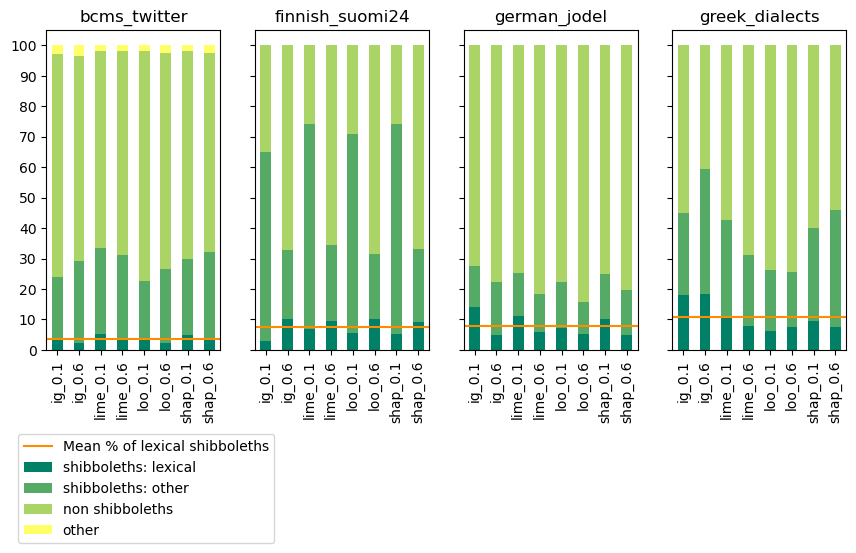

In [88]:
fig, axes = plt.subplots(nrows=1, ncols=4, sharey='row', figsize=(10,4))
all_overview[all_overview['dataset'] == 'bcms_twitter'].set_index('method').plot(kind='bar', stacked=True, title="bcms_twitter",  colormap="summer", ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'finnish_suomi24'].set_index('method').plot(kind='bar', stacked=True, title="finnish_suomi24",  colormap="summer", ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'german_jodel'].set_index('method').plot(kind='bar', stacked=True, title="german_jodel",  colormap="summer", ax=axes[2], legend=False)
all_overview[all_overview['dataset'] == 'greek_dialects'].set_index('method').plot(kind='bar', stacked=True, title="greek_dialects",  colormap="summer", ax=axes[3], legend=False)                                                                                 
axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)
axes[3].set_xlabel(None)

axes[0].axhline(mean_twit, color='darkorange', linestyle='-')
axes[1].axhline(mean_suomi24, color='darkorange', linestyle='-')
axes[2].axhline(mean_jodel, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
axes[3].axhline(mean_greek, color='darkorange', linestyle='-')

ax=axes[2]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.4), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.2, hspace=0.5
                   )
fig.figure.savefig('experiment2-overview-per_dataset.pdf', bbox_inches='tight')

### RESULTS PER DATASET, PER CLASS

## BCMS SETIMES

In [89]:
bcms_setimes_df2 = bcms_setimes_df.set_index('file', drop=True)
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note
file,,,,,,,,,
list1,liječniku,hr,0.340325,0.60,True,yes,lex,NaN,jek
list1,slijedili,hr,0.232197,0.64,True,no,phon,NaN,jek
list1,razvitkom,hr,0.212817,0.75,True,yes,morph-d,NaN,NaN
list1,natjecateljskom,hr,0.194636,0.63,True,yes,lex,NaN,NaN
list1,sarachini,hr,0.190969,0.63,False,no,named entity,NaN,NaN
...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN


In [90]:
bcms_setimes_methods_df

,method
average,average
list1,loo_0.6
list2,loo_0.1
list3,shap_0.6
list4,shap_0.1
list5,ig_0.1
list6,lime_0.6
list7,lime_0.1
list8,ig_0.6


In [91]:
bcms_setimes_df2 = bcms_setimes_df2.join(bcms_setimes_methods_df, how='left', on=None)

In [92]:
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
list1,liječniku,hr,0.340325,0.60,True,yes,lex,NaN,jek,loo_0.6
list1,slijedili,hr,0.232197,0.64,True,no,phon,NaN,jek,loo_0.6
list1,razvitkom,hr,0.212817,0.75,True,yes,morph-d,NaN,NaN,loo_0.6
list1,natjecateljskom,hr,0.194636,0.63,True,yes,lex,NaN,NaN,loo_0.6
list1,sarachini,hr,0.190969,0.63,False,no,named entity,NaN,NaN,loo_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,ig_0.6
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,ig_0.6
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,ig_0.6
list8,ignorisati,sr,0.361948,0.62,False,yes,morph-d,NaN,NaN,ig_0.6


In [93]:
methods = ['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6']
classes = ['hr', 'sr']

counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = bcms_setimes_df2[(bcms_setimes_df2['method'] == m) & (bcms_setimes_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] != 'lex')])
        nonshib = len(work_df[(work_df['shibboleth'] == 'no')])
        other = len(work_df[(work_df['shibboleth'] != 'yes') & (work_df['shibboleth'] != 'no')])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])


In [94]:
counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
counts_df

Lexical  Non-lexical  Non shibboleth  Other
ig_0.1   hr       14           14              72      0
         sr        6           44              48      2
ig_0.6   hr       23           15              62      0
         sr       14           81               5      0
lime_0.1 hr        7           22              70      1
         sr       15           66              12      7
lime_0.6 hr       22           17              60      1
         sr       15           68              15      2
loo_0.1  hr        9           17              71      3
         sr        5           32              60      3
loo_0.6  hr       21           13              66      0
         sr       12           57              28      3
shap_0.1 hr       10           18              71      1
         sr        5           27              64      4
shap_0.6 hr       22           18              60      0
         sr       11           54              35      0

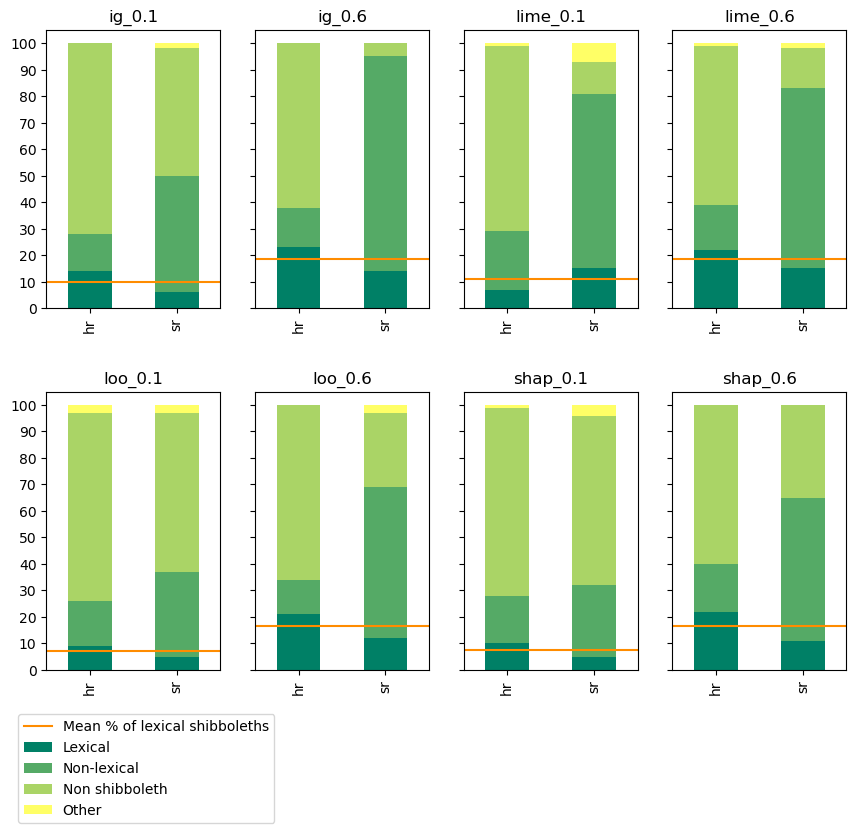

In [95]:
fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))

idx = -1
for i in range(0,2):
    for j in range(0,4):
        idx += 1  
        m = methods[idx]
        counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
        mean = counts_df.loc[m]['Lexical'].mean()
       # if i == 1 and j == 3:
        axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')

axes[0, 0].set_yticks(range(0, 105, 10))
axes[0, 0].set_ylim(0, 105)

axes[1, 0].set_yticks(range(0, 105, 10))
axes[1, 0].set_ylim(0, 105)

ax=axes[1,3]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.2, hspace=0.3
                   )

fig.figure.savefig('bcms_setimes_perclass.pdf', bbox_inches='tight')

In [96]:
def make_graphs_per_class(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

## BCMS TWITTER

In [97]:
bcms_twitter_df2 = bcms_twitter_df.set_index('file', drop=True)
bcms_twitter_df2 = bcms_twitter_df2.join(bcms_twitter_methods_df, how='left' or 'inner', on=None)

In [98]:
bcms_twitter_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
list1,čarobna,bs,0.706716,0.875000,NaN,no,unm,NaN,NaN,lime_0.6
list1,čarolije,bs,0.658181,0.656250,NaN,no,unm,NaN,NaN,lime_0.6
list1,čarolija,bs,0.643859,0.968750,NaN,no,unm,NaN,NaN,lime_0.6
list1,fancyasfuck,bs,0.621885,0.739583,NaN,no,foreign,NaN,NaN,lime_0.6
list1,allah,bs,0.591824,0.791667,NaN,yes,lex,spel,NaN,lime_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,lime_0.1
list8,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,lime_0.1
list8,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,lime_0.1
list8,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,lime_0.1


In [99]:
classes = bcms_twitter_df2['label'].sort_values().unique()
classes

array(['bs', 'hr', 'me', 'sr'], dtype=object)

In [100]:
methods = bcms_twitter_df2['method'].sort_values().unique()

In [101]:
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [102]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = bcms_twitter_df2[(bcms_twitter_df2['method'] == m) & (bcms_twitter_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] != 'lex')])
        nonshib = len(work_df[(work_df['shibboleth'] == 'no')])
        other = len(work_df[(work_df['shibboleth'] != 'yes') & (work_df['shibboleth'] != 'no')])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

{'ig_0.1': {'bs': [14, 0, 82, 4, 100],
  'hr': [1, 3, 90, 6, 100],
  'me': [1, 7, 91, 1, 100],
  'sr': [0, 69, 30, 1, 100]},
 'ig_0.6': {'bs': [4, 0, 89, 7, 100],
  'hr': [5, 5, 85, 5, 100],
  'me': [0, 10, 89, 1, 100],
  'sr': [0, 93, 6, 1, 100]},
 'lime_0.1': {'bs': [14, 0, 84, 2, 100],
  'hr': [5, 3, 91, 1, 100],
  'me': [0, 22, 76, 2, 100],
  'sr': [2, 88, 8, 2, 100]},
 'lime_0.6': {'bs': [6, 0, 92, 2, 100],
  'hr': [8, 7, 81, 4, 100],
  'me': [0, 13, 86, 1, 100],
  'sr': [1, 89, 9, 1, 100]},
 'loo_0.1': {'bs': [10, 0, 90, 0, 100],
  'hr': [2, 1, 96, 1, 100],
  'me': [1, 7, 88, 4, 100],
  'sr': [0, 70, 28, 2, 100]},
 'loo_0.6': {'bs': [3, 0, 94, 3, 100],
  'hr': [5, 8, 83, 4, 100],
  'me': [0, 12, 86, 2, 100],
  'sr': [1, 77, 21, 1, 100]},
 'shap_0.1': {'bs': [16, 0, 81, 3, 100],
  'hr': [2, 3, 92, 3, 100],
  'me': [1, 10, 87, 2, 100],
  'sr': [0, 87, 13, 0, 100]},
 'shap_0.6': {'bs': [6, 0, 87, 7, 100],
  'hr': [10, 8, 80, 2, 100],
  'me': [0, 13, 87, 0, 100],
  'sr': [0, 91, 8, 1

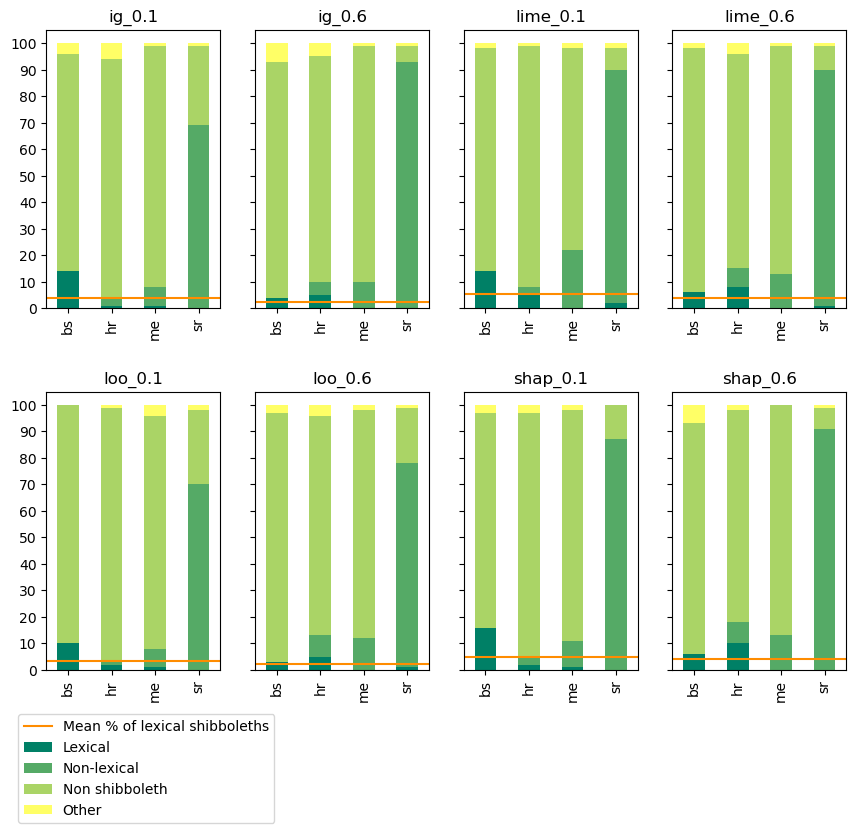

In [103]:
make_graphs_per_class(counts, 'bcms_twitter')

### SCANDINAVIAN_SLIDE

In [104]:
scandinavian_slide_df2 = scandinavian_slide_df.set_index('file', drop=True)
scandinavian_slide_df2 = scandinavian_slide_df2.join(scandinavian_slide_methods_df, how='left', on=None)
scandinavian_slide_df2['method'].value_counts()

lime_0.1    400
ig_0.1      400
shap_0.1    400
shap_0.6    400
loo_0.1     400
loo_0.6     400
ig_0.6      400
lime_0.6    400
Name: method, dtype: int64

In [105]:
classes = scandinavian_slide_df2['label'].sort_values().unique()
classes

array(['da', 'nb', 'nn', 'sv'], dtype=object)

In [106]:
methods = scandinavian_slide_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [107]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = scandinavian_slide_df2[(scandinavian_slide_df2['method'] == m) & (scandinavian_slide_df2['label'] == c)]
        lex = len(work_df[work_df['LexShib'] == True])
        nonlex = len(work_df[work_df['NonLexShib'] == True])
        nonshib = len(work_df[work_df['NotShib'] == True])
        other = len(work_df[work_df['Typo_Unk'] == True])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts


{'ig_0.1': {'da': [24, 59, 12, 5, 100],
  'nb': [6, 53, 33, 8, 100],
  'nn': [20, 46, 27, 7, 100],
  'sv': [47, 47, 4, 2, 100]},
 'ig_0.6': {'da': [9, 75, 16, 0, 100],
  'nb': [7, 28, 65, 0, 100],
  'nn': [19, 51, 30, 0, 100],
  'sv': [26, 61, 13, 0, 100]},
 'lime_0.1': {'da': [25, 66, 9, 0, 100],
  'nb': [6, 34, 54, 6, 100],
  'nn': [8, 65, 23, 4, 100],
  'sv': [38, 52, 7, 3, 100]},
 'lime_0.6': {'da': [12, 71, 17, 0, 100],
  'nb': [4, 34, 62, 0, 100],
  'nn': [29, 38, 32, 1, 100],
  'sv': [18, 66, 16, 0, 100]},
 'loo_0.1': {'da': [20, 67, 12, 1, 100],
  'nb': [6, 32, 57, 5, 100],
  'nn': [11, 62, 23, 4, 100],
  'sv': [40, 52, 7, 1, 100]},
 'loo_0.6': {'da': [11, 73, 16, 0, 100],
  'nb': [3, 35, 62, 0, 100],
  'nn': [26, 28, 46, 0, 100],
  'sv': [26, 60, 14, 0, 100]},
 'shap_0.1': {'da': [26, 70, 3, 1, 100],
  'nb': [5, 43, 44, 8, 100],
  'nn': [15, 59, 23, 3, 100],
  'sv': [49, 50, 1, 0, 100]},
 'shap_0.6': {'da': [9, 80, 11, 0, 100],
  'nb': [4, 39, 57, 0, 100],
  'nn': [29, 28, 43,

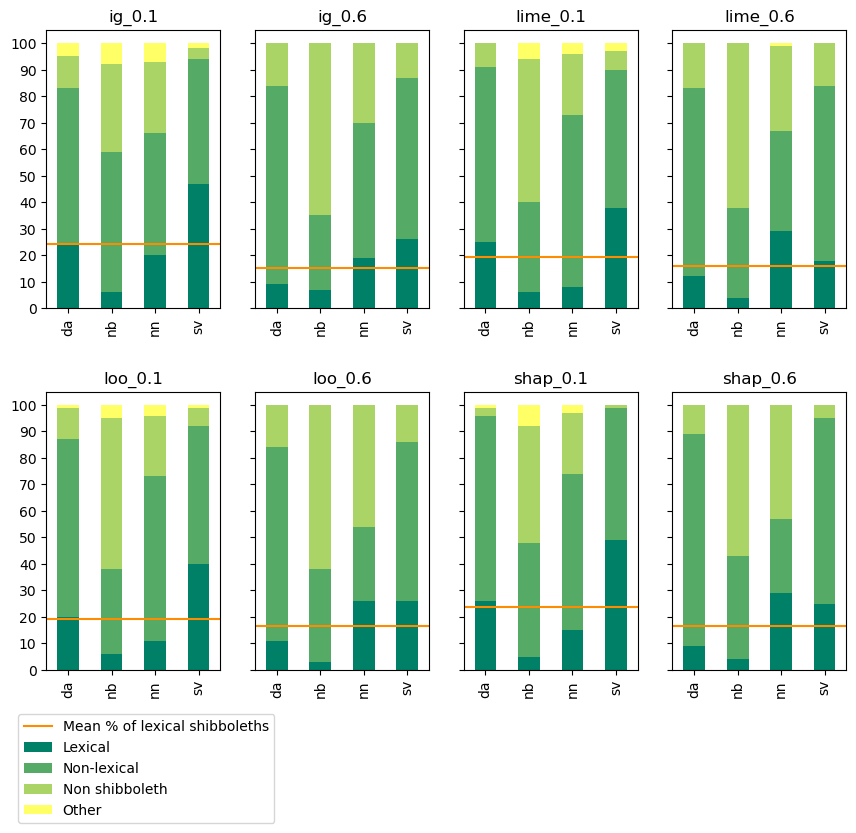

In [108]:
make_graphs_per_class(counts, 'scandinavian_slide')

### PREPARING ESTONIAN-VORO 

In [109]:
estonian_voro_df2 = estonian_voro_df.set_index('file', drop=True)
estonian_voro_df2 = estonian_voro_df2.join(estonian_voro_methods_df, how='left', on=None)
estonian_voro_df2['method'].value_counts()

ig_0.6      200
ig_0.1      200
loo_0.1     200
shap_0.6    200
shap_0.1    200
loo_0.6     200
lime_0.6    200
lime_0.1    200
Name: method, dtype: int64

In [110]:
classes = estonian_voro_df2['label'].sort_values().unique()
classes

array(['est', 'vro'], dtype=object)

In [111]:
methods = estonian_voro_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [112]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = estonian_voro_df2[(estonian_voro_df2['method'] == m) & (estonian_voro_df2['label'] == c)]
        lex = len(work_df[work_df['lexshib'] == 1])
        nonlex = len(work_df[work_df['nonlexshib'] == 1])
        nonshib = len(work_df[work_df['noshib'] == 1])
        other = len(work_df[work_df['unk'] == 1])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#estonian_voro_shib_distro = estonian_voro_df[estonian_voro_df['lexshib']==1].groupby('file').size().to_frame(name="lex shib")
#estonian_voro_shib_distro['non lex shib'] = estonian_voro_df[estonian_voro_df['nonlexshib']==1].groupby('file').size()
#estonian_voro_shib_distro['non shib'] = estonian_voro_df[estonian_voro_df['noshib']==1].groupby('file').size()
#estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['unk']==1].groupby('file').size()

{'ig_0.1': {'est': [44, 51, 3, 2, 100], 'vro': [29, 63, 4, 4, 100]},
 'ig_0.6': {'est': [20, 74, 5, 1, 100], 'vro': [15, 73, 11, 1, 100]},
 'lime_0.1': {'est': [35, 57, 2, 6, 100], 'vro': [22, 75, 0, 3, 100]},
 'lime_0.6': {'est': [13, 68, 18, 1, 100], 'vro': [5, 71, 24, 0, 100]},
 'loo_0.1': {'est': [29, 61, 7, 3, 100], 'vro': [24, 71, 0, 5, 100]},
 'loo_0.6': {'est': [14, 64, 21, 1, 100], 'vro': [4, 77, 18, 1, 100]},
 'shap_0.1': {'est': [36, 61, 2, 1, 100], 'vro': [19, 74, 2, 5, 100]},
 'shap_0.6': {'est': [18, 76, 6, 0, 100], 'vro': [4, 77, 18, 1, 100]}}

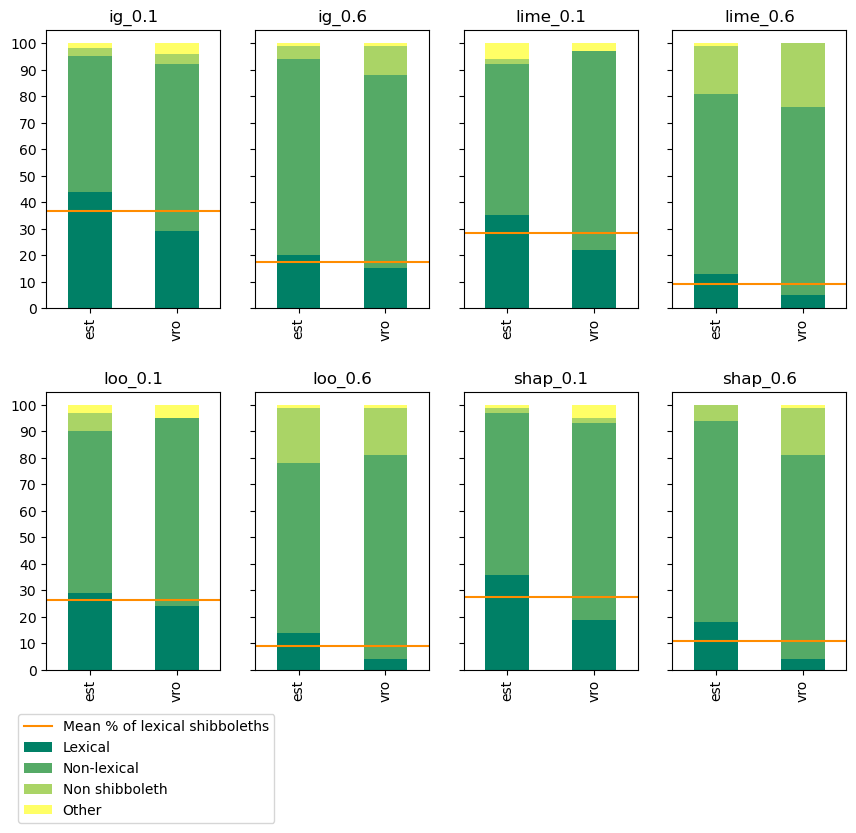

In [113]:
make_graphs_per_class(counts, 'estonian_voro')

### PREPARING JODEL DATA

In [114]:
german_jodel_df2 = german_jodel_df.set_index('file', drop=True)
german_jodel_df2 = german_jodel_df2.join(german_jodel_methods_df, how='left', on=None)
german_jodel_df2['method'].value_counts()

ig_0.1      400
ig_0.6      400
lime_0.1    400
lime_0.6    400
shap_0.6    400
shap_0.1    400
loo_0.1     400
loo_0.6     400
Name: method, dtype: int64

In [115]:
classes = german_jodel_df2['label'].sort_values().unique()
classes

array(['AT', 'CH', 'DE_N', 'DE_S'], dtype=object)

In [116]:
methods = german_jodel_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [117]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = german_jodel_df2[(german_jodel_df2['method'] == m) & (german_jodel_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['code'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['code'] != 'lex')])
        nonshib = len(work_df[work_df['shibboleth'] == 'no'])
        other = 0
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#german_jodel_shib_distro = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
#german_jodel_shib_distro['nonlex shib'] = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] != 'lex')].groupby('file').size()
#german_jodel_shib_distro['non shib'] = german_jodel_df[german_jodel_df['shibboleth'] == 'no'].groupby('file').size()

{'ig_0.1': {'AT': [14, 11, 75, 0, 100],
  'CH': [18, 42, 40, 0, 100],
  'DE_N': [2, 1, 97, 0, 100],
  'DE_S': [23, 0, 77, 0, 100]},
 'ig_0.6': {'AT': [8, 5, 87, 0, 100],
  'CH': [10, 64, 26, 0, 100],
  'DE_N': [0, 0, 100, 0, 100],
  'DE_S': [2, 0, 98, 0, 100]},
 'lime_0.1': {'AT': [16, 17, 67, 0, 100],
  'CH': [13, 40, 47, 0, 100],
  'DE_N': [2, 0, 98, 0, 100],
  'DE_S': [13, 0, 87, 0, 100]},
 'lime_0.6': {'AT': [5, 5, 90, 0, 100],
  'CH': [16, 45, 39, 0, 100],
  'DE_N': [0, 0, 100, 0, 100],
  'DE_S': [2, 0, 98, 0, 100]},
 'loo_0.1': {'AT': [11, 17, 72, 0, 100],
  'CH': [8, 43, 49, 0, 100],
  'DE_N': [0, 0, 100, 0, 100],
  'DE_S': [10, 0, 90, 0, 100]},
 'loo_0.6': {'AT': [6, 6, 88, 0, 100],
  'CH': [13, 36, 51, 0, 100],
  'DE_N': [0, 0, 100, 0, 100],
  'DE_S': [2, 0, 98, 0, 100]},
 'shap_0.1': {'AT': [15, 14, 71, 0, 100],
  'CH': [16, 45, 39, 0, 100],
  'DE_N': [0, 0, 100, 0, 100],
  'DE_S': [9, 0, 91, 0, 100]},
 'shap_0.6': {'AT': [4, 8, 88, 0, 100],
  'CH': [14, 51, 35, 0, 100],
  'D

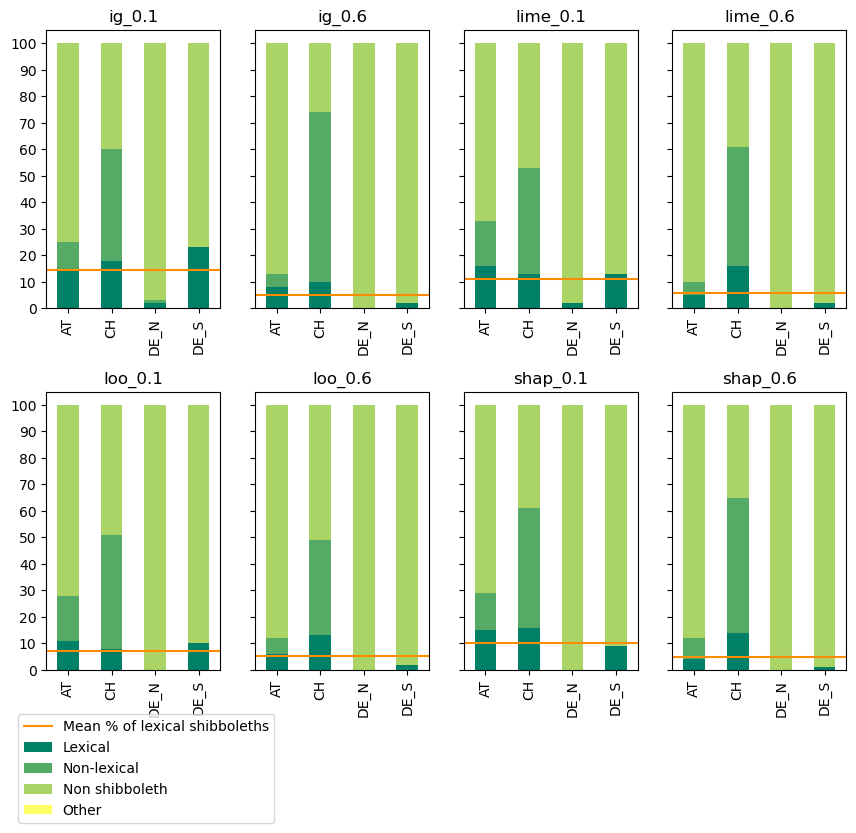

In [118]:
make_graphs_per_class(counts, 'german_jodel')

### PREPARING GREEK DATA

In [119]:
greek_dialects_df2 = greek_dialects_df.set_index('file', drop=True)
greek_dialects_df2 = greek_dialects_df2.join(greek_dialects_methods_df, how='left', on=None)
greek_dialects_df2['method'].value_counts()

ig_0.6      400
shap_0.1    400
loo_0.1     400
loo_0.6     400
shap_0.6    400
ig_0.1      400
lime_0.6    400
lime_0.1    400
Name: method, dtype: int64

In [120]:
classes = greek_dialects_df2['label'].sort_values().unique()
classes

array(['CRE', 'CYP', 'NOR', 'PON'], dtype=object)

In [121]:
methods = greek_dialects_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [122]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = greek_dialects_df2[(greek_dialects_df2['method'] == m) & (greek_dialects_df2['label'] == c)]
        lex = len(work_df[work_df['feature'] == 'Lex'])
        nonlex = len(work_df[(work_df['feature'] != 'NE') & (work_df['feature'] != 'Unmarked') & (work_df['feature'] != 'Lex')])
        nonshib = len(work_df[(work_df['feature'] == 'NE') | (work_df['feature'] == 'Unmarked')])
        other = 0
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#greek_dialects_shib_distro = greek_dialects_df[greek_dialects_df['feature'] == 'Lex'].groupby('file').size().to_frame(name='lex shib')
#greek_dialects_shib_distro['nonlex shib'] = greek_dialects_df[(greek_dialects_df['feature'] != 'NE') & (greek_dialects_df['feature'] != 'Unmarked') & (greek_dialects_df['feature'] != 'Lex')].groupby('file').size()
#greek_dialects_shib_distro['non shib'] = greek_dialects_df[(greek_dialects_df['feature'] == 'NE') | (greek_dialects_df['feature'] == 'Unmarked')].groupby('file').size()

{'ig_0.1': {'CRE': [25, 23, 52, 0, 100],
  'CYP': [6, 7, 87, 0, 100],
  'NOR': [10, 60, 30, 0, 100],
  'PON': [31, 18, 51, 0, 100]},
 'ig_0.6': {'CRE': [25, 38, 37, 0, 100],
  'CYP': [6, 31, 63, 0, 100],
  'NOR': [10, 56, 34, 0, 100],
  'PON': [33, 39, 28, 0, 100]},
 'lime_0.1': {'CRE': [19, 48, 33, 0, 100],
  'CYP': [12, 22, 66, 0, 100],
  'NOR': [7, 46, 47, 0, 100],
  'PON': [4, 12, 84, 0, 100]},
 'lime_0.6': {'CRE': [11, 27, 62, 0, 100],
  'CYP': [1, 4, 95, 0, 100],
  'NOR': [6, 46, 48, 0, 100],
  'PON': [13, 17, 70, 0, 100]},
 'loo_0.1': {'CRE': [7, 21, 72, 0, 100],
  'CYP': [8, 13, 79, 0, 100],
  'NOR': [5, 35, 60, 0, 100],
  'PON': [5, 11, 84, 0, 100]},
 'loo_0.6': {'CRE': [15, 14, 71, 0, 100],
  'CYP': [2, 5, 93, 0, 100],
  'NOR': [7, 32, 61, 0, 100],
  'PON': [6, 21, 73, 0, 100]},
 'shap_0.1': {'CRE': [8, 25, 67, 0, 100],
  'CYP': [14, 15, 71, 0, 100],
  'NOR': [9, 68, 23, 0, 100],
  'PON': [7, 14, 79, 0, 100]},
 'shap_0.6': {'CRE': [9, 38, 53, 0, 100],
  'CYP': [6, 44, 50, 0, 

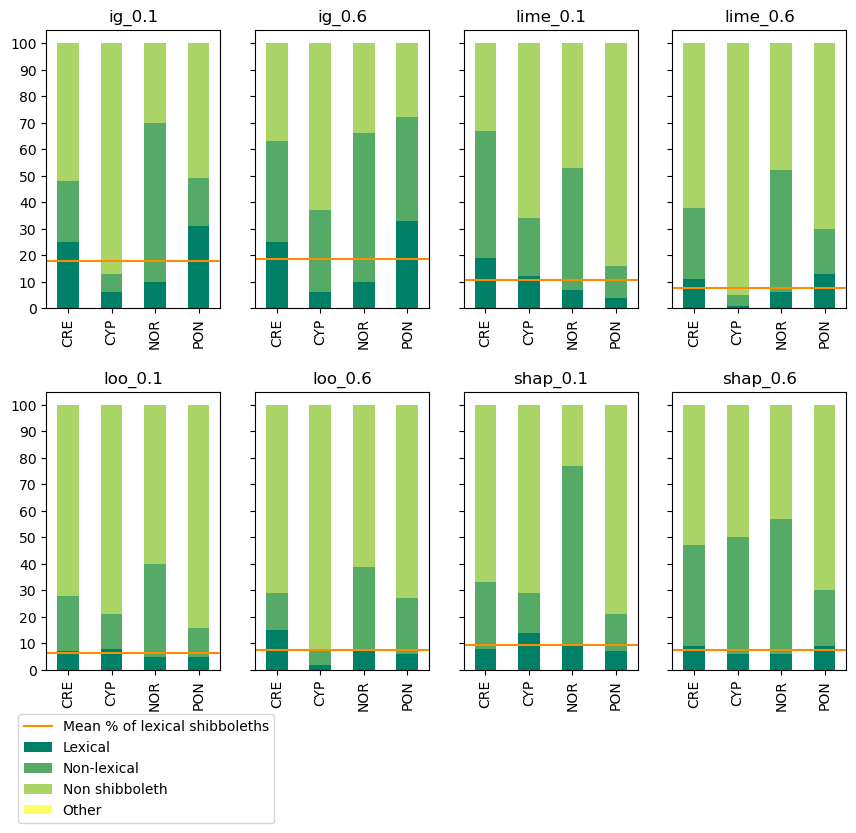

In [123]:
make_graphs_per_class(counts, 'greek_dialects')

### PREPARING FINNISH DATA

In [180]:
finnish_suomi24_df2 = finnish_suomi24_df.set_index('file', drop=True)
finnish_suomi24_df2 = finnish_suomi24_df2.join(finnish_suomi24_methods_df, how='left', on=None)
finnish_suomi24_df2['method'].value_counts()

loo_0.1     300
lime_0.1    300
ig_0.1      300
shap_0.1    300
lime_0.6    221
loo_0.6     207
shap_0.6    206
ig_0.6      186
Name: method, dtype: int64

In [181]:
sums = finnish_suomi24_df2.groupby(['method', 'label']).size()
sums

method    label
ig_0.1    east     100
          north    100
          west     100
ig_0.6    east      63
          north     64
          west      59
lime_0.1  east     100
          north    100
          west     100
lime_0.6  east      72
          north     77
          west      72
loo_0.1   east     100
          north    100
          west     100
loo_0.6   east      71
          north     68
          west      68
shap_0.1  east     100
          north    100
          west     100
shap_0.6  east      67
          north     71
          west      68
dtype: int64

In [182]:
methods = finnish_suomi24_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [183]:
classes = finnish_suomi24_df2['label'].sort_values().unique()
classes

array(['east', 'north', 'west'], dtype=object)

In [184]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = finnish_suomi24_df2[(finnish_suomi24_df2['method'] == m) & (finnish_suomi24_df2['label'] == c)]
        lex = len(work_df[work_df['lex_other_not'] == 'lex'])
        nonlex = len(work_df[work_df['lex_other_not'] == 'other'])
        nonshib = len(work_df[work_df['lex_other_not'] == 'not'])
        other = 0
       # sum = lex + nonlex + nonshib + other
        lex = round(lex / sums[m][c] * 100, 1)
        nonlex = round(nonlex / sums[m][c] * 100, 1)
        nonshib = round(nonshib / sums[m][c] * 100, 1)
        sum2 = lex + nonlex + nonshib
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum2])
counts

# finnish_suomi24_shib_distro = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'lex'].groupby('file').size().to_frame(name='lex shib')
# finnish_suomi24_shib_distro['nonlex shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'other'].groupby('file').size()
# finnish_suomi24_shib_distro['non shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] ==  'not'].groupby('file').size()

{'ig_0.1': {'east': [0.0, 91.0, 9.0, 0, 100.0],
  'north': [1.0, 53.0, 46.0, 0, 100.0],
  'west': [8.0, 42.0, 50.0, 0, 100.0]},
 'ig_0.6': {'east': [9.5, 30.2, 60.3, 0, 100.0],
  'north': [7.8, 25.0, 67.2, 0, 100.0],
  'west': [13.6, 11.9, 74.6, 0, 100.1]},
 'lime_0.1': {'east': [7.0, 87.0, 6.0, 0, 100.0],
  'north': [2.0, 52.0, 46.0, 0, 100.0],
  'west': [12.0, 62.0, 26.0, 0, 100.0]},
 'lime_0.6': {'east': [9.7, 34.7, 55.6, 0, 100.0],
  'north': [6.5, 26.0, 67.5, 0, 100.0],
  'west': [12.5, 13.9, 73.6, 0, 100.0]},
 'loo_0.1': {'east': [6.0, 81.0, 13.0, 0, 100.0],
  'north': [1.0, 55.0, 44.0, 0, 100.0],
  'west': [10.0, 60.0, 30.0, 0, 100.0]},
 'loo_0.6': {'east': [9.9, 25.4, 64.8, 0, 100.1],
  'north': [7.4, 25.0, 67.6, 0, 100.0],
  'west': [13.2, 13.2, 73.5, 0, 99.9]},
 'shap_0.1': {'east': [5.0, 91.0, 4.0, 0, 100.0],
  'north': [1.0, 61.0, 38.0, 0, 100.0],
  'west': [10.0, 54.0, 36.0, 0, 100.0]},
 'shap_0.6': {'east': [10.4, 31.3, 58.2, 0, 99.9],
  'north': [7.0, 26.8, 66.2, 0, 100.

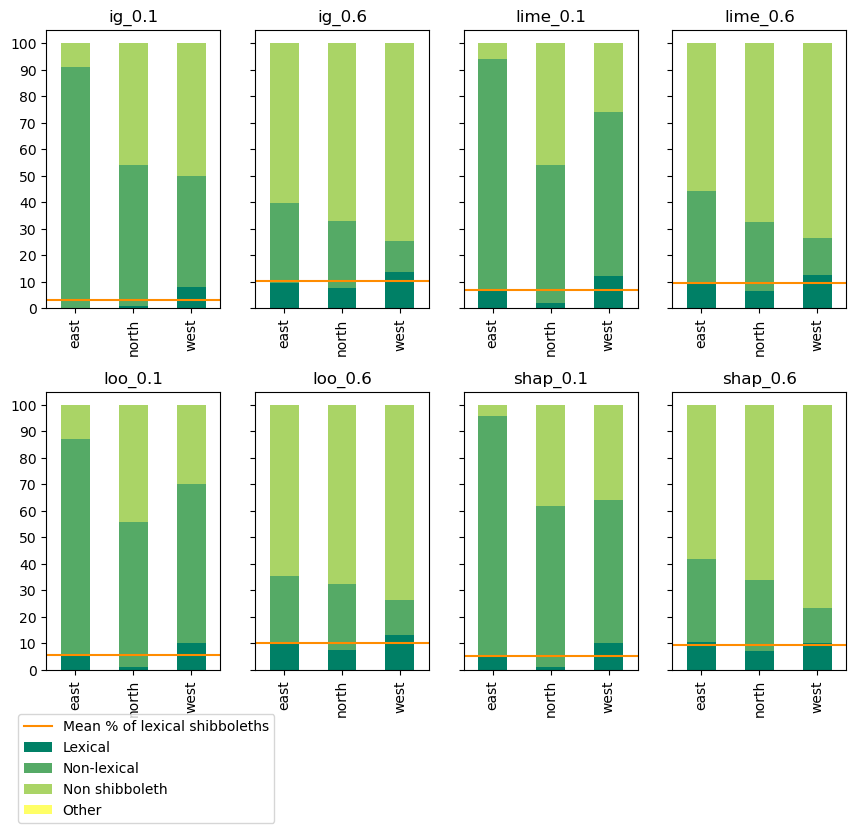

In [185]:
make_graphs_per_class(counts, 'finnish_suomi24')

In [129]:
def make_graphs_per_class(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

### LEVELS OF LINGUISTIC STRUCTURE

In [131]:
def make_graphs_per_level(df, methods, classes, dataset):
    
    work_df = df
    methods = methods
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel.pdf'

    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
        
    
    i = 0
    j = -1
    for m in methods:
        j += 1
        for c in classes:
            try: ## added
                tmp = work_df.loc[m, c] ## indendted
                tmp['sum'] = tmp['count'].sum()
                tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
                tmp = tmp.drop(columns=['count', 'sum']).transpose()
                tmp['label'] = c
                tmp = tmp.set_index('label')
                dfs.append(tmp)
            except KeyError:
                pass
    
        df_to_plot = pd.concat(dfs).sort_index(axis=1)    
        df_to_plot.plot(kind='bar', stacked=True, title = m, colormap='summer', ax = axes[i,j], legend=False)
    
        dfs = []
        
        if j == 3:
            i += 1
            j = -1
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    axes[0,0].set_xlabel(None)
    axes[0,1].set_xlabel(None)
    axes[0,2].set_xlabel(None)
    axes[0,3].set_xlabel(None)
    axes[1,0].set_xlabel(None)
    axes[1,1].set_xlabel(None)
    axes[1,2].set_xlabel(None)
    axes[1,3].set_xlabel(None)
    
    ax=axes[0,2]
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

In [254]:
def make_sel_graph_per_level(df, method, classes, dataset):
    
    work_df = df
    m = method
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel_sel.pdf'

    #fig  = plt.plot(figsize=(5,4))
    
      
    for c in classes:
        try: ## added
            tmp = work_df.loc[m, c] ## indented
            tmp['sum'] = tmp['count'].sum()
            tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
            tmp = tmp.drop(columns=['count', 'sum']).transpose()
            tmp['label'] = c
            tmp = tmp.set_index('label')
            dfs.append(tmp)
        except KeyError:
            pass
    
    df_to_plot = pd.concat(dfs).sort_index(axis=1)    
    df_to_plot.plot(kind='bar', stacked=True, title = ds, colormap='summer', figsize=(5,4), xlabel=method).legend(bbox_to_anchor=(1.0, 1.0)).figure.savefig(outfile, bbox_inches='tight')
    
    
   # plt.set_yticks(range(0, 105, 10))
   # plt.set_ylim(0, 105)
    
#    axes[1, 0].set_yticks(range(0, 105, 10))
#    axes[1, 0].set_ylim(0, 105)
#    
#    axes[0,0].set_xlabel(None)
#    axes[0,1].set_xlabel(None)
#    axes[0,2].set_xlabel(None)
#    axes[0,3].set_xlabel(None)
#    axes[1,0].set_xlabel(None)
#    axes[1,1].set_xlabel(None)
#    axes[1,2].set_xlabel(None)
#    axes[1,3].set_xlabel(None)
    
#    ax=axes[0,2]
#    handles, labels = ax.get_legend_handles_labels()
#    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
#   # plt.subplots_adjust(left=0.1, right=0.9, 
#                        top=0.9, bottom=0.1, 
#                        wspace=0.2, hspace=0.3
#                       )
    
   # plt.figure.savefig(outfile, bbox_inches='tight')

### PREPARING BCMS SETIMES

In [132]:
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
list1,liječniku,hr,0.340325,0.60,True,yes,lex,NaN,jek,loo_0.6
list1,slijedili,hr,0.232197,0.64,True,no,phon,NaN,jek,loo_0.6
list1,razvitkom,hr,0.212817,0.75,True,yes,morph-d,NaN,NaN,loo_0.6
list1,natjecateljskom,hr,0.194636,0.63,True,yes,lex,NaN,NaN,loo_0.6
list1,sarachini,hr,0.190969,0.63,False,no,named entity,NaN,NaN,loo_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,ig_0.6
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,ig_0.6
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,ig_0.6
list8,ignorisati,sr,0.361948,0.62,False,yes,morph-d,NaN,NaN,ig_0.6


In [133]:
f1 = bcms_setimes_df2[['feature', 'label']]
len(f1)

1600

In [134]:
f2 = bcms_setimes_df2[['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
len(f2)

99

In [135]:
feature_df = pd.concat([f1, f2])
feature_df['file'] = feature_df.index
feature_df = feature_df.reset_index().drop(columns=('index'))
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df
# per method, per class

,feature,label,method
0,lex,hr,loo_0.6
1,phon,hr,loo_0.6
2,morph-d,hr,loo_0.6
3,lex,hr,loo_0.6
7,phon,hr,loo_0.6
...,...,...,...
1669,morph-f,hr,lime_0.1
1673,phon,sr,lime_0.1
1680,phon,hr,ig_0.6
1686,phon,hr,ig_0.6


In [136]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [137]:
classes = feature_df['label'].sort_values().unique()
classes

array(['hr', 'sr'], dtype=object)

In [138]:
bcms_setimes_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_setimes_levels_df

count
method   label feature       
ig_0.1   hr    lex         14
               morph-d      4
               phon        64
               spel         1
         sr    lex          7
...                       ...
shap_0.6 hr    spel         1
         sr    lex         11
               morph-d     11
               morph-f      2
               phon        43

[70 rows x 1 columns]

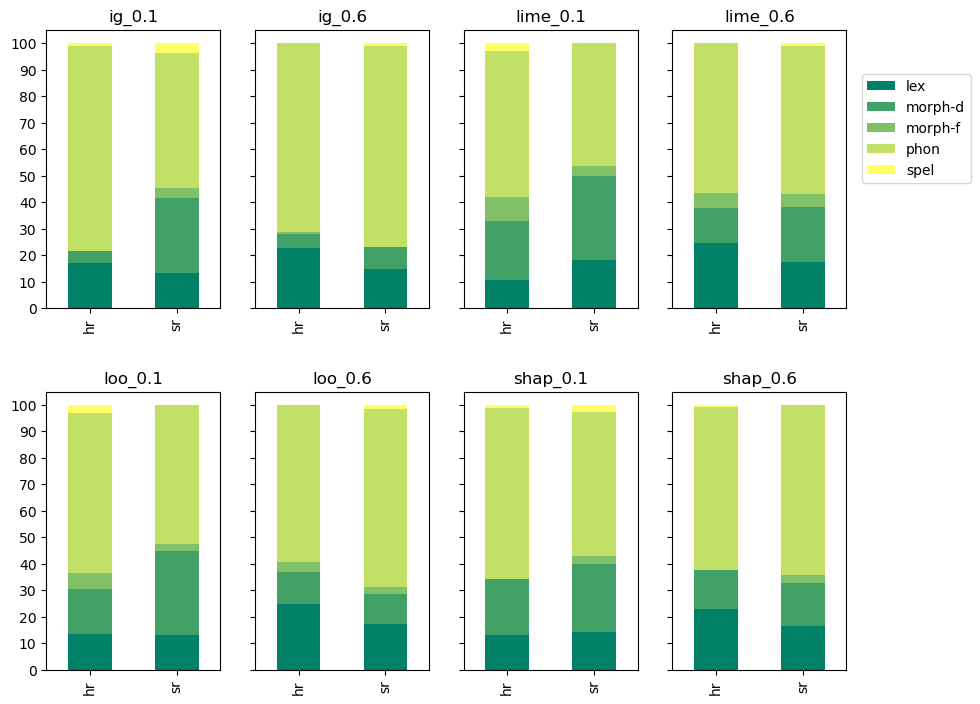

In [139]:
make_graphs_per_level(bcms_setimes_levels_df, methods, classes, 'bcms_setimes')

### PREPARING BCMS TWITTER

In [275]:
bcms_twitter_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
list1,čarobna,bs,0.706716,0.875000,NaN,no,unm,NaN,NaN,lime_0.6
list1,čarolije,bs,0.658181,0.656250,NaN,no,unm,NaN,NaN,lime_0.6
list1,čarolija,bs,0.643859,0.968750,NaN,no,unm,NaN,NaN,lime_0.6
list1,fancyasfuck,bs,0.621885,0.739583,NaN,no,foreign,NaN,NaN,lime_0.6
list1,allah,bs,0.591824,0.791667,NaN,yes,lex,spel,NaN,lime_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,lime_0.1
list8,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,lime_0.1
list8,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,lime_0.1
list8,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,lime_0.1


In this setup, it is possible to have non-shibboleths annotated for linguistic features

(a word can be marked, just not specific to a single variety)

In [276]:
f1 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] == 'yes'][['feature', 'label']]
f1

,feature,label
list1,lex,bs
list1,lex,bs
list1,lex,bs
list1,lex,bs
list1,lex,bs
...,...,...
list8,phon,sr
list8,phon,sr
list8,phon,sr
list8,phon,sr


In [277]:
f2 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] ==  'yes'][['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
f2

,label,feature
list1,bs,spel
list1,bs,spel
list1,hr,nonminimal
list1,hr,morph-d
list1,hr,nonminimal
...,...,...
list8,me,spel
list8,sr,morph-f
list8,sr,nonminimal
list8,sr,morph-f


In [278]:
feature_df = pd.concat([f1, f2])
feature_df['file'] = feature_df.index
feature_df = feature_df.reset_index().drop(columns=('index'))
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df

,feature,label,method
0,lex,bs,loo_0.6
1,lex,bs,loo_0.6
2,lex,bs,loo_0.6
3,lex,bs,loo_0.6
4,lex,bs,loo_0.6
...,...,...,...
1024,spel,me,ig_0.6
1025,spel,me,ig_0.6
1026,spel,me,ig_0.6
1027,morph-f,sr,ig_0.6


In [279]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [280]:
classes = feature_df['label'].sort_values().unique()
classes

array(['bs', 'hr', 'me', 'sr'], dtype=object)

In [281]:
bcms_twitter_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_twitter_levels_df

count
method   label feature       
ig_0.1   bs    lex          3
               spel         2
         hr    lex          5
               morph-f      2
               phon         6
...                       ...
shap_0.6 me    lex          1
               phon        10
               spel         4
         sr    morph-f      1
               phon        87

[87 rows x 1 columns]

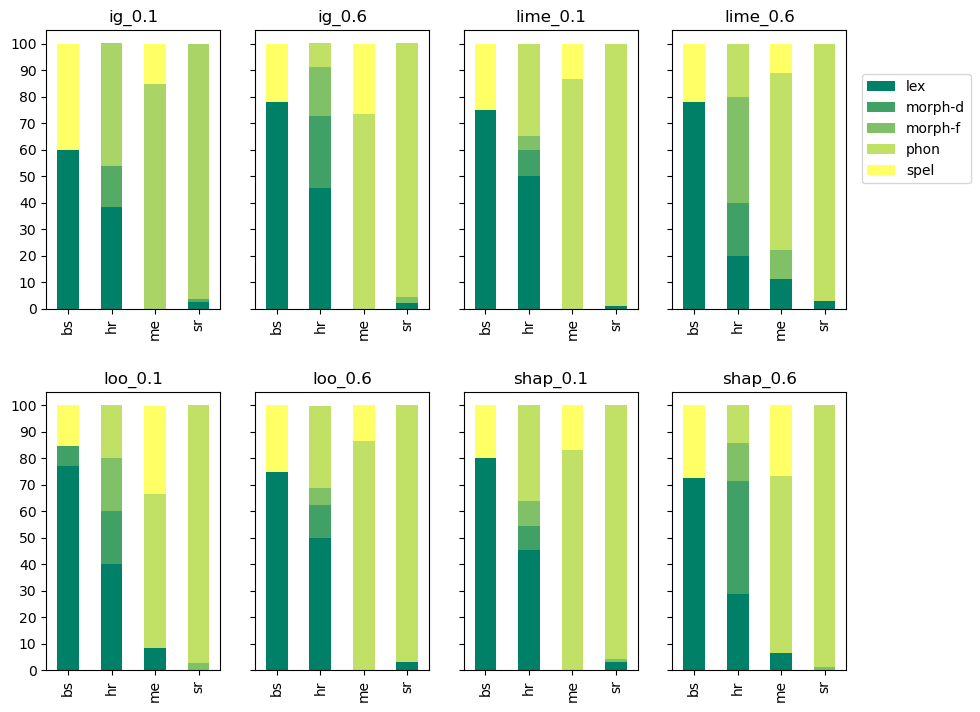

In [147]:
make_graphs_per_level(bcms_twitter_levels_df, methods, classes, 'bcms_twitter')

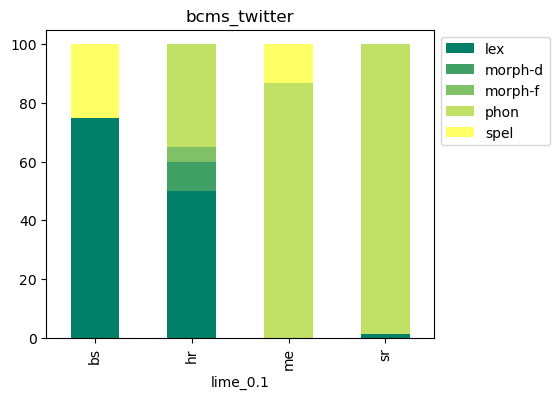

In [282]:
make_sel_graph_per_level(bcms_twitter_levels_df, 'lime_0.1', classes, 'bcms_twitter')
#def make_sel_graph_per_level(df, method, classes, dataset):

## PREPARING FINNISH

In [256]:
finnish_suomi24_df2

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,method
list1,0,ollunna,east,0.379162,0.818182,morph,other,shap_0.6
list1,1,hää,east,0.366869,0.989899,lex,lex,shap_0.6
list1,2,aeka,east,0.361476,0.676768,phon,other,shap_0.6
list1,3,minnuu,east,0.349316,0.828283,phon,other,shap_0.6
list1,4,vaen,east,0.336384,0.848485,phon,other,shap_0.6
...,...,...,...,...,...,...,...,...
list8,295,mukulat,west,0.175638,0.101010,not,not,shap_0.1
list8,296,kauhavalaanen,west,0.175430,0.101010,phon,other,shap_0.1
list8,297,pikkase.kerros,west,0.174050,0.101010,not,not,shap_0.1
list8,298,vitsikäs,west,0.173803,0.101010,not,not,shap_0.1


In [257]:
feature_df = finnish_suomi24_df2[(finnish_suomi24_df2['lex_other_not'] == 'lex') | (finnish_suomi24_df2['lex_other_not'] == 'other')][['category', 'label', 'method']]
feature_df = feature_df[feature_df.category.str.contains('morph|lex|phon')]
feature_df

,category,label,method
list1,morph,east,shap_0.6
list1,lex,east,shap_0.6
list1,phon,east,shap_0.6
list1,phon,east,shap_0.6
list1,phon,east,shap_0.6
...,...,...,...
list8,phon,west,shap_0.1
list8,morph,west,shap_0.1
list8,phon,west,shap_0.1
list8,lex,west,shap_0.1


In [258]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [259]:
classes = feature_df['label'].sort_values().unique()
classes

array(['east', 'north', 'west'], dtype=object)

In [260]:
finnish_suomi24_levels_df = feature_df.groupby(['method', 'label', 'category']).size().to_frame(name='count')
finnish_suomi24_levels_df

count
method   label category       
ig_0.1   east  morph        24
               phon         67
         north lex           1
               morph        22
               phon         27
...                        ...
shap_0.6 north morph         8
               phon         11
         west  lex           7
               morph         1
               phon          8

[71 rows x 1 columns]

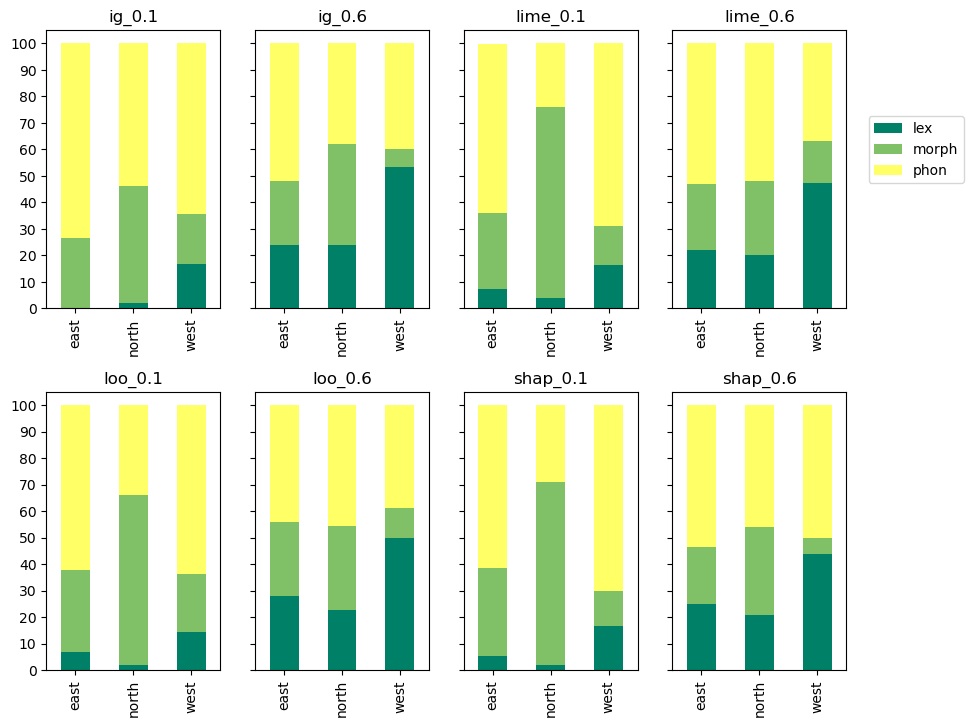

In [231]:
make_graphs_per_level(finnish_suomi24_levels_df, methods, classes, 'finnish_suomi24-test')

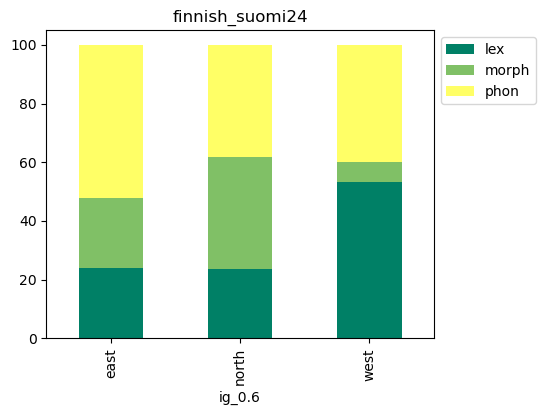

In [261]:
make_sel_graph_per_level(finnish_suomi24_levels_df, 'ig_0.6', classes, 'finnish_suomi24')

### PREPARING GREEK 

In [262]:
greek_dialects_df2['feature'].sort_values().unique()

array(['I', 'Lex', 'Morph', 'NE', 'Other', 'Phon', 'Spell', 'Unmarked',
       'ΝΕ'], dtype=object)

In [263]:
feature_df = greek_dialects_df2[['feature', 'label', 'method']]
feature_df = feature_df[feature_df.feature.str.contains('Morph|Lex|Phon|Spell')]
feature_df

,feature,label,method
list1,Morph,CRE,ig_0.6
list1,Morph,CRE,ig_0.6
list1,Morph,CRE,ig_0.6
list1,Lex,CRE,ig_0.6
list1,Phon,CRE,ig_0.6
...,...,...,...
list8,Morph,PON,lime_0.1
list8,Morph,PON,lime_0.1
list8,Lex,PON,lime_0.1
list8,Morph,PON,lime_0.1


In [264]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [265]:
classes = feature_df['label'].sort_values().unique()
classes

array(['CRE', 'CYP', 'NOR', 'PON'], dtype=object)

In [266]:
greek_dialects_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
greek_dialects_levels_df

count
method   label feature       
ig_0.1   CRE   Lex         25
               Morph       14
               Phon         9
         CYP   Lex          6
               Morph        2
...                       ...
shap_0.6 NOR   Morph       13
               Phon        38
         PON   Lex          9
               Morph       13
               Phon         8

[96 rows x 1 columns]

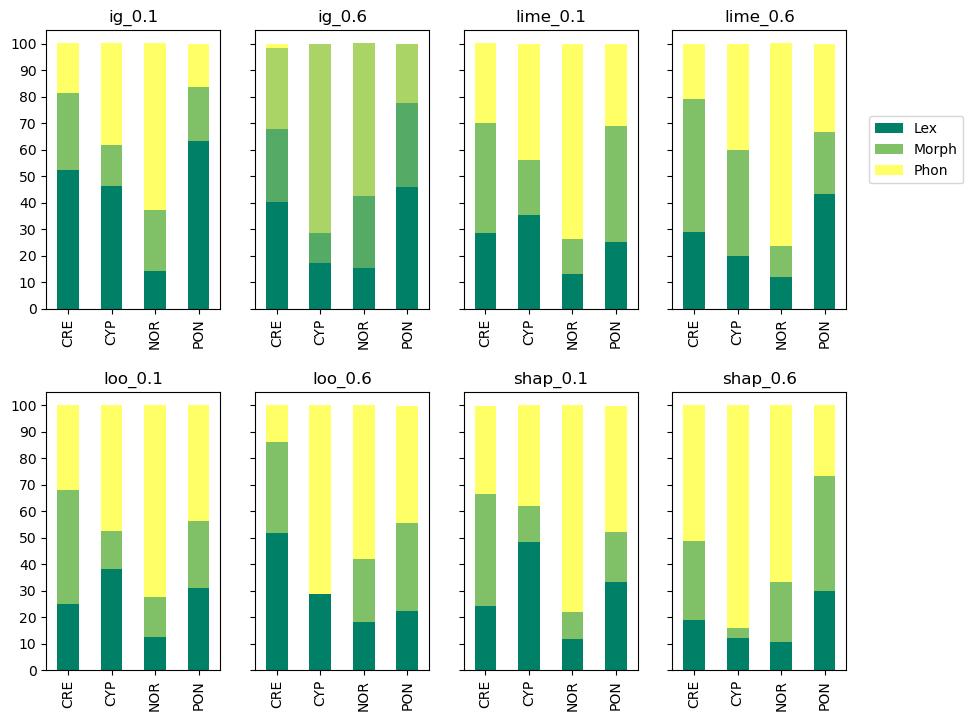

In [267]:
make_graphs_per_level(greek_dialects_levels_df, methods, classes, 'greek_dialects')

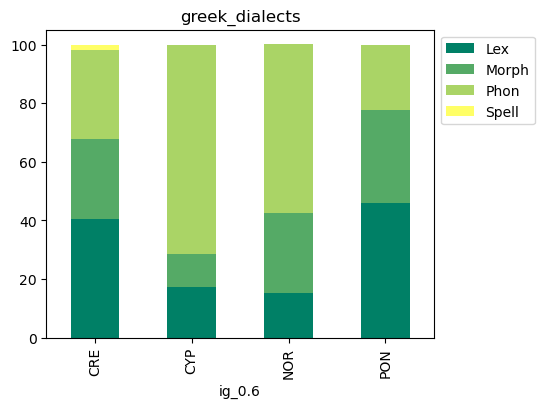

In [268]:
make_sel_graph_per_level(greek_dialects_levels_df, 'ig_0.6', classes, 'greek_dialects')

### PREPARING JODEL

In [269]:
german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes']['code'].sort_values().unique()

array(['lex', 'morph', 'other', 'phon', 'spell'], dtype=object)

In [270]:
feature_df = german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes'][['label', 'method', 'code']]
feature_df = feature_df[feature_df.code.str.contains('morph|lex|phon|spell')]
feature_df

,label,method,code
list1,AT,ig_0.1,morph
list1,AT,ig_0.1,morph
list1,AT,ig_0.1,morph
list1,AT,ig_0.1,lex
list1,AT,ig_0.1,lex
...,...,...,...
list8,CH,loo_0.6,phon
list8,CH,loo_0.6,morph
list8,CH,loo_0.6,phon
list8,DE_S,loo_0.6,lex


In [271]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [272]:
classes = feature_df['label'].sort_values().unique()
classes

array(['AT', 'CH', 'DE_N', 'DE_S'], dtype=object)

In [273]:
german_jodel_levels_df = feature_df.groupby(['method', 'label', 'code']).size().to_frame(name='count')
german_jodel_levels_df

count
method   label code        
ig_0.1   AT    lex       14
               morph      7
               phon       4
         CH    lex       18
               morph      4
               phon      38
         DE_N  lex        2
         DE_S  lex       23
ig_0.6   AT    lex        8
               morph      5
         CH    lex       10
               morph     15
               phon      49
         DE_S  lex        2
lime_0.1 AT    lex       16
               morph     16
               phon       1
         CH    lex       13
               morph     13
               phon      27
         DE_N  lex        2
         DE_S  lex       13
lime_0.6 AT    lex        5
               morph      5
         CH    lex       16
               morph     18
               phon      27
         DE_S  lex        2
loo_0.1  AT    lex       11
               morph     15
               phon       2
         CH    lex        8
               morph     14
               phon      27
               spell      2
         DE_S  lex       10
loo_0.6  AT    lex        6
               morph      6
         CH    lex       13
               morph     14
               phon      21
               spell      1
         DE_S  lex        2
shap_0.1 AT    lex       15
               morph     12
               phon       2
         CH    lex       16
               morph     10
               phon      33
               spell      2
         DE_S  lex        9
shap_0.6 AT    lex        4
               morph      7
               phon       1
         CH    lex       14
               morph     20
               phon      31
         DE_S  lex        1

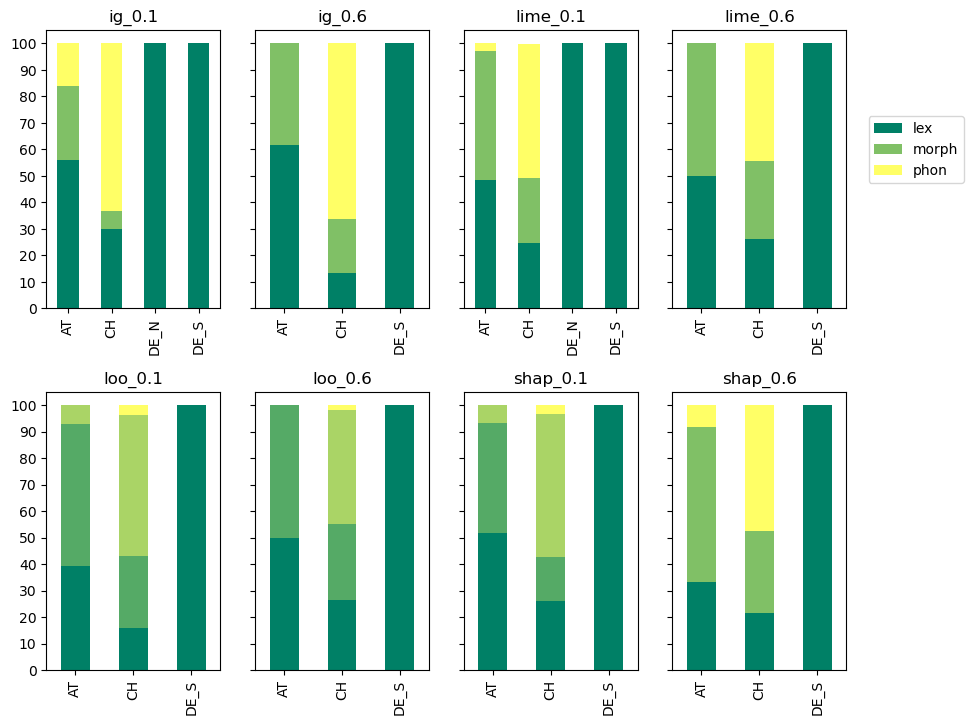

In [245]:
make_graphs_per_level(german_jodel_levels_df, methods, classes, 'german_jodel')

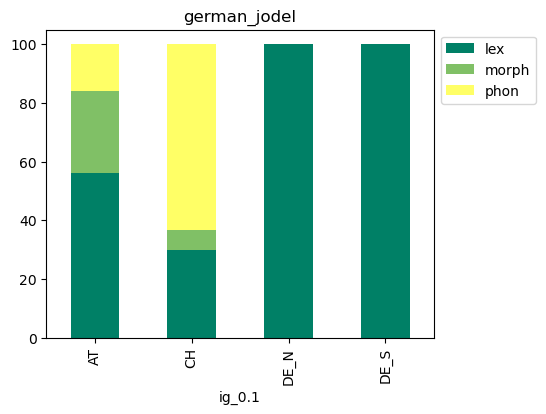

In [274]:
make_sel_graph_per_level(german_jodel_levels_df, 'ig_0.1', classes, 'german_jodel')

### PREPARING SLIDE

In [167]:
scandinavian_slide_df2

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,method
list1,0,uddannelsesinstitutionerne,da,0.996353,0.10,False,NaN,utdannelsesinstitusjonene,NaN,NaN,False,True,True,True,False,False,False,False,True,lime_0.1
list1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,lime_0.1
list1,2,forsigtigere,da,0.992772,0.10,False,NaN,forsiktigere,forsiktigare,försiktigare,False,False,False,True,False,False,False,False,True,lime_0.1
list1,3,standardindstillingerne,da,0.992396,0.10,False,NaN,standardinnstillingene,standardinnstilling?,standardinställning?/lemma,False,True,True,False,False,False,False,False,True,lime_0.1
list1,4,historiebøger,da,0.987946,0.10,False,NaN,bøker,NaN,böcker,False,True,False,True,False,False,False,False,True,lime_0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
list8,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,lime_0.6
list8,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,lime_0.6
list8,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,lime_0.6
list8,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,lime_0.6


In [168]:
feature_df = scandinavian_slide_df2[(scandinavian_slide_df2['LexShib'] == True) | \
                                    (scandinavian_slide_df2['NonLexShib'] == True)][['Morph', 'Phon_Spell', 'LexShib', 'method', 'label']]
feature_df['LexShib'] = feature_df['LexShib'].replace(True, 'Lex')
feature_df['Morph'] = feature_df['Morph'].replace(True, 'Morph')
feature_df['Phon_Spell'] = feature_df['Phon_Spell'].replace(True, 'Phon_Spell')
feature_df

,Morph,Phon_Spell,LexShib,method,label
list1,Morph,Phon_Spell,False,lime_0.1,da
list1,False,Phon_Spell,False,lime_0.1,da
list1,False,Phon_Spell,False,lime_0.1,da
list1,Morph,False,False,lime_0.1,da
list1,False,Phon_Spell,False,lime_0.1,da
...,...,...,...,...,...
list8,False,False,Lex,lime_0.6,sv
list8,False,Phon_Spell,False,lime_0.6,sv
list8,Morph,Phon_Spell,False,lime_0.6,sv
list8,Morph,Phon_Spell,False,lime_0.6,sv


In [169]:
tmp1 = feature_df[['Morph', 'method', 'label']]
tmp1['feature'] = tmp1['Morph']
tmp1 = tmp1.drop(columns=['Morph'])
tmp1

/tmp/ipykernel_5936/2651079599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['feature'] = tmp1['Morph']


,method,label,feature
list1,lime_0.1,da,Morph
list1,lime_0.1,da,False
list1,lime_0.1,da,False
list1,lime_0.1,da,Morph
list1,lime_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Morph
list8,lime_0.6,sv,Morph


In [170]:
tmp2 = feature_df[['LexShib', 'method', 'label']]
tmp2['feature'] = tmp2['LexShib']
tmp2 = tmp2.drop(columns=['LexShib'])
tmp2

/tmp/ipykernel_5936/2370939929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['feature'] = tmp2['LexShib']


,method,label,feature
list1,lime_0.1,da,False
list1,lime_0.1,da,False
list1,lime_0.1,da,False
list1,lime_0.1,da,False
list1,lime_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,Lex
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False


In [171]:
tmp3 = feature_df[['Phon_Spell', 'method', 'label']]
tmp3['feature'] = tmp3['Phon_Spell']
tmp3 = tmp3.drop(columns=['Phon_Spell'])
tmp3

/tmp/ipykernel_5936/2819609312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp3['feature'] = tmp3['Phon_Spell']


,method,label,feature
list1,lime_0.1,da,Phon_Spell
list1,lime_0.1,da,Phon_Spell
list1,lime_0.1,da,Phon_Spell
list1,lime_0.1,da,False
list1,lime_0.1,da,Phon_Spell
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [172]:
feature_df = pd.concat([tmp1, tmp2, tmp3])
feature_df = feature_df[feature_df['feature'] != False]
feature_df

,method,label,feature
list1,lime_0.1,da,Morph
list1,lime_0.1,da,Morph
list1,lime_0.1,da,Morph
list1,lime_0.1,da,Morph
list1,lime_0.1,da,Morph
...,...,...,...
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [173]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [174]:
classes = feature_df['label'].sort_values().unique()
classes

array(['da', 'nb', 'nn', 'sv'], dtype=object)

In [175]:
scandinavian_slide_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
scandinavian_slide_levels_df

count
method   label feature          
ig_0.1   da    Lex            24
               Morph          14
               Phon_Spell     48
         nb    Lex             6
               Morph          29
...                          ...
shap_0.6 nn    Morph          13
               Phon_Spell     17
         sv    Lex            25
               Morph          31
               Phon_Spell     55

[96 rows x 1 columns]

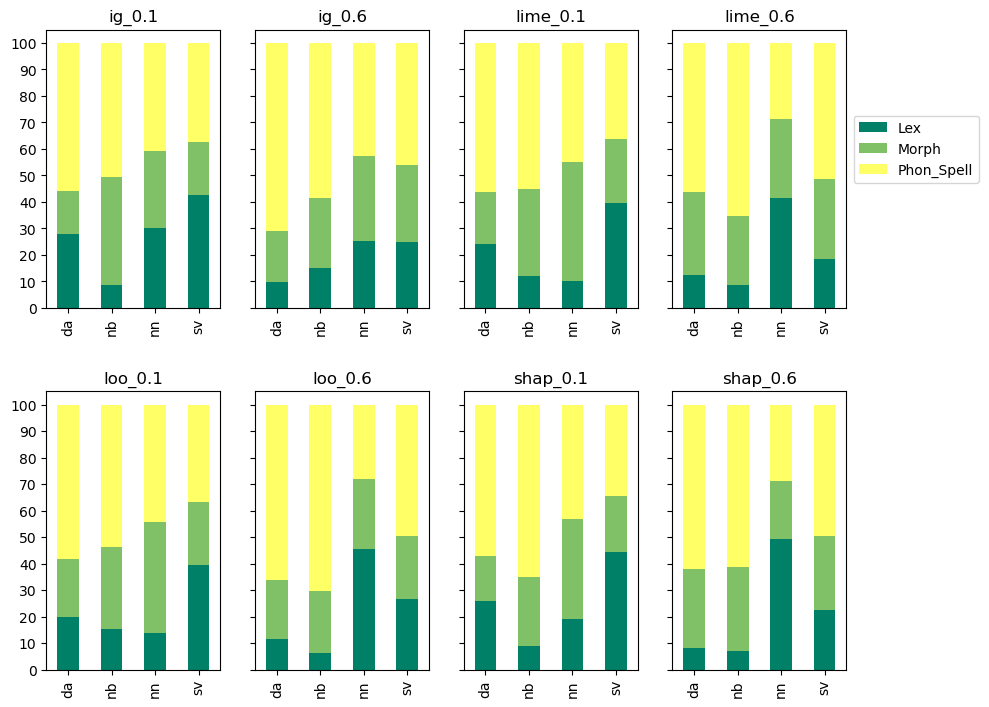

In [176]:
make_graphs_per_level(scandinavian_slide_levels_df, methods, classes, 'scandinavian_slide')